In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
import random
import time

# Prepare Input

In [4]:
class BrainMRIDataset(Dataset):
    """
    Dataset for Brain MRI with real and counterfactual age and gender information
    """
    def __init__(self, data_dir, participants_file, transform=None, img_size=128):
        self.data_dir = data_dir
        self.transform = transform
        self.img_size = img_size

        self.participants_df = pd.read_excel(participants_file)
        self.participants_df['subject_age'] = self.participants_df['subject_age'].round().astype(int)
        self.participants_df['gender_code'] = self.participants_df['subject_sex'].map({'m': 0, 'f': 1})
        
        valid_subjects = []
        for subject_id in self.participants_df['subject_id']:
            file_path = os.path.join(data_dir, subject_id, 'anat', f"{subject_id}_T1w.nii.gz")
            if os.path.exists(file_path):
                valid_subjects.append(subject_id)
        
        self.participants_df = self.participants_df[self.participants_df['subject_id'].isin(valid_subjects)]
        print(f"Found {len(self.participants_df)} samples with valid MRI data")
    
    def __len__(self):
        return len(self.participants_df)
    
    def _get_middle_slices(self, subject_id):
        try:
            file_path = os.path.join(self.data_dir, subject_id, 'anat', f"{subject_id}_T1w.nii.gz")
            img = nib.load(file_path)
            img_data = img.get_fdata()
            
            mid_z = img_data.shape[2] // 2
            mid_x = img_data.shape[0] // 2
            mid_y = img_data.shape[1] // 2
            
            slices = [
                img_data[:, :, mid_z],  # Axial
                img_data[mid_x, :, :],  # Sagittal
                img_data[:, mid_y, :]   # Coronal
            ]
                
            processed_slices = []
            for slice_data in slices:
                # Normalize to [0, 1]
                if slice_data.max() > slice_data.min():
                    slice_data = (slice_data - slice_data.min()) / (slice_data.max() - slice_data.min())
                
                # Convert to tensor and resize
                tensor_slice = torch.from_numpy(slice_data).float().unsqueeze(0)  # Shape: [1, H, W]
                resized_slice = F.interpolate(
                    tensor_slice.unsqueeze(0),  # Shape: [1, 1, H, W]
                    size=(self.img_size, self.img_size),
                    mode='bilinear',
                    align_corners=False
                ).squeeze(0)  # Shape: [1, H, W]
                
                processed_slices.append(resized_slice)
            
            combined_slices = torch.cat(processed_slices, dim=0)  # Shape: [3, H, W]
            
            if self.transform:
                combined_slices = self.transform(combined_slices)
            
            return combined_slices  # Shape: [3, H, W]
            
        except Exception as e:
            print(f"Error when processing {subject_id}: {e}")
            return torch.zeros((3, self.img_size, self.img_size), dtype=torch.float32)  # Shape: [3, 128, 128]
    
    def categorize_age(self, age):
        """
        Categorize age into three groups: <30, 30-50, >50
        """
        if age < 30:
            return torch.tensor([1, 0, 0], dtype=torch.float32)
        elif age <= 50:
            return torch.tensor([0, 1, 0], dtype=torch.float32)
        else:
            return torch.tensor([0, 0, 1], dtype=torch.float32)
    
    def __getitem__(self, idx):
        """
        Retrieve a sample from the dataset
        """
        real_info = self.participants_df.iloc[idx]
        real_id = real_info['subject_id']
        real_age = real_info['subject_age']
        real_gender = real_info['gender_code']
        
        valid_indices = [
            i for i in range(len(self)) 
            if i != idx and abs(self.participants_df.iloc[i]['subject_age'] - real_age) > 30
        ]
        if not valid_indices:
            cf_info = real_info
        else:
            cf_idx = random.choice(valid_indices)
            cf_info = self.participants_df.iloc[cf_idx]
        
        cf_id = cf_info['subject_id']
        cf_age = cf_info['subject_age']
        cf_gender = cf_info['gender_code']

        real_img = self._get_middle_slices(real_id)  # Shape: [3, H, W]
        
        real_condition = torch.cat([self.categorize_age(real_age), torch.tensor([real_gender], dtype=torch.float32)])  # Shape: [4]
        cf_condition = torch.cat([self.categorize_age(cf_age), torch.tensor([cf_gender], dtype=torch.float32)])  # Shape: [4]
        
        real_raw_condition = torch.tensor([real_age, real_gender], dtype=torch.float32)  # Shape: [2]
        cf_raw_condition = torch.tensor([cf_age, cf_gender], dtype=torch.float32)  # Shape: [2]
        
        return {
            'real_id': real_id,
            'cf_id': cf_id,
            'real_img': real_img,
            'real_condition': real_condition,
            'cf_condition': cf_condition,
            'real_raw_condition': real_raw_condition,
            'cf_raw_condition': cf_raw_condition
        }

In [7]:
transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.01),  # Gaussian noise
])

dataset = BrainMRIDataset(data_dir='data', participants_file='data/participants_1.xlsx', transform=transform, img_size=128)

Found 4924 samples with valid MRI data


In [8]:
sample = dataset[0]

print("Real ID:", sample['real_id'])
print("Counterfactual ID:", sample['cf_id'])
print("Real image shape:", sample['real_img'].shape)
print("Real condition (normalized):", sample['real_condition'])
print("Counterfactual condition (normalized):", sample['cf_condition'])
print("Real condition (raw):", sample['real_raw_condition'])
print("Counterfactual condition (raw):", sample['cf_raw_condition'])

Real ID: sub-BrainAge000019
Counterfactual ID: sub-BrainAge021293
Real image shape: torch.Size([3, 128, 128])
Real condition (normalized): tensor([0., 1., 0., 0.])
Counterfactual condition (normalized): tensor([0., 0., 1., 0.])
Real condition (raw): tensor([44.,  0.])
Counterfactual condition (raw): tensor([86.,  0.])


In [9]:
weights = 1.0 / dataset.participants_df['gender_code'].value_counts()[dataset.participants_df['gender_code']].values
sampler = WeightedRandomSampler(weights, len(weights))
dataloader = DataLoader(dataset, batch_size=4, sampler=sampler)

In [10]:
batch = next(iter(dataloader))

print("Real image batch shape:", batch['real_img'].shape)
print("Real condition (normalized):", batch['real_condition'], batch['real_condition'].shape)
print("Counterfactual condition (normalized):", batch['cf_condition'], batch['cf_condition'].shape)
print("Real condition (raw):", batch['real_raw_condition'], batch['real_raw_condition'].shape)
print("Counterfactual condition (raw):", batch['cf_raw_condition'], batch['cf_raw_condition'].shape)
print("Gender distribution in batch:", batch['real_raw_condition'][:, 1].long().bincount().tolist())
print("Real IDs:", batch['real_id'])
print("Counterfactual IDs:", batch['cf_id'])

Real image batch shape: torch.Size([4, 3, 128, 128])
Real condition (normalized): tensor([[1., 0., 0., 1.],
        [0., 1., 0., 1.],
        [1., 0., 0., 1.],
        [1., 0., 0., 0.]]) torch.Size([4, 4])
Counterfactual condition (normalized): tensor([[0., 0., 1., 1.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.],
        [0., 0., 1., 0.]]) torch.Size([4, 4])
Real condition (raw): tensor([[20.,  1.],
        [49.,  1.],
        [19.,  1.],
        [20.,  0.]]) torch.Size([4, 2])
Counterfactual condition (raw): tensor([[59.,  1.],
        [88.,  0.],
        [58.,  0.],
        [70.,  0.]]) torch.Size([4, 2])
Gender distribution in batch: [1, 3]
Real IDs: ['sub-BrainAge019436', 'sub-BrainAge019872', 'sub-BrainAge011442', 'sub-BrainAge005677']
Counterfactual IDs: ['sub-BrainAge018875', 'sub-BrainAge021163', 'sub-BrainAge021289', 'sub-BrainAge021091']


# Generator

In [5]:
def weights_init_normal(model):
    """
    Initialize weights for Conv2d, BatchNorm2d, and Linear layers, skip if weight is None
    """
    classname = model.__class__.__name__
    if classname == "Conv2d":
        torch.nn.init.normal_(model.weight.data, 0.0, 0.1)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0.0)
    elif classname.find("BatchNorm2d") != -1:
        if hasattr(model, 'weight') and model.weight is not None:
            torch.nn.init.normal_(model.weight.data, 1.0, 0.02)
        if hasattr(model, 'bias') and model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0.0)
    elif classname.find("Linear") != -1:
        torch.nn.init.normal_(model.weight.data, 0.0, 0.1)
        if model.bias is not None:
            torch.nn.init.constant_(model.bias.data, 0.0)

class ConditionalBatchNorm2d(nn.Module):
    """
    Conditional Batch Normalization for integrating condition into feature maps
    """
    def __init__(self, num_features, condition_dim=4):
        super().__init__()
        self.bn = nn.BatchNorm2d(num_features, affine=False)
        self.embed = nn.Linear(condition_dim, num_features * 2)
        
    def forward(self, x, condition):
        out = self.bn(x)
        gamma, beta = self.embed(condition).chunk(2, 1)
        gamma = gamma.view(-1, x.size(1), 1, 1)
        beta = beta.view(-1, x.size(1), 1, 1)
        out = gamma * out + beta
        return out

class AttentionGate(nn.Module):
    """
    Attention gate to focus on important regions during decoding
    """
    def __init__(self, in_channels, gating_channels, inter_channels):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x, g):
        """
        Args:
            x: Skip connection feature map [B, in_channels, H, W]
            g: Gating signal from deeper layer [B, gating_channels, H, W]
        Returns:
            Attention-weighted feature map [B, in_channels, H, W]
        """
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class ConvBlock(nn.Module):
    """
    Convolutional block with conditional batch normalization and dropout
    """
    def __init__(self, in_channels, out_channels, condition_dim=4, dropout_p=0.3):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = ConditionalBatchNorm2d(out_channels, condition_dim)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = ConditionalBatchNorm2d(out_channels, condition_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout_p)
        
    def forward(self, x, condition):
        x = self.conv1(x)
        x = self.bn1(x, condition)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.bn2(x, condition)
        x = self.relu(x)
        x = self.dropout(x)
        return x

class SpatialTransformer(nn.Module):
    """
    Spatial transformer to apply deformation to images
    """
    def __init__(self):
        super(SpatialTransformer, self).__init__()
    
    def forward(self, src, flow):
        """
        Args:
            src: Source image tensor [B, C, H, W]
            flow: Deformation vector field tensor [B, 2, H, W]
        Returns:
            Transformed image tensor [B, C, H, W]
        """
        B, C, H, W = src.size()
        
        grid_y, grid_x = torch.meshgrid(
            torch.linspace(-1, 1, H, device=src.device),
            torch.linspace(-1, 1, W, device=src.device),
            indexing='ij'
        )
        grid = torch.stack((grid_x, grid_y), dim=2).unsqueeze(0)  # Shape: [1, H, W, 2]
        grid = grid.expand(B, H, W, 2)  # Shape: [B, H, W, 2]
        
        flow_grid = flow.permute(0, 2, 3, 1)  # Shape: [B, H, W, 2]
        flow_grid = flow_grid / torch.tensor([W/2, H/2], device=flow.device)
        
        sample_grid = grid + flow_grid  # Shape: [B, H, W, 2]
        
        output = F.grid_sample(src, sample_grid, mode='bilinear', padding_mode='border', align_corners=True)
        
        return output

class ScalingAndSquaring(nn.Module):
    """
    Scaling and squaring layer to integrate velocity field into deformation field
    """
    def __init__(self, n_steps=5):
        super(ScalingAndSquaring, self).__init__()
        self.n_steps = n_steps
        self.transformer = SpatialTransformer()
        
    def forward(self, velocity):
        """
        Args:
            velocity: Velocity field tensor [B, 2, H, W]
        Returns:
            Deformation field tensor [B, 2, H, W]
        """
        flow = velocity / (2 ** self.n_steps)
        
        for _ in range(self.n_steps):
            flow = flow + self.transformer(flow, flow)
            
        return flow

class Generator(nn.Module):
    """
    U-Net Generator with conditional batch normalization, attention gates, and scaling and squaring
    """
    def __init__(self, in_channels=3, condition_dim=4, init_features=32):
        """
        Args:
            in_channels: Input channels (3 for image slices: axial, sagittal, coronal)
            condition_dim: Dimension of condition vector (4 for age categories + gender)
            init_features: Initial number of features
        """
        super(Generator, self).__init__()
        
        self.encoder1 = ConvBlock(in_channels, init_features, condition_dim)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder2 = ConvBlock(init_features, init_features*2, condition_dim)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder3 = ConvBlock(init_features*2, init_features*4, condition_dim)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.bridge = ConvBlock(init_features*4, init_features*4, condition_dim)
        
        self.upconv3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(init_features*4, init_features*4, kernel_size=3, padding=1)
        )
        self.att3 = AttentionGate(init_features*4, init_features*4, init_features*2)
        self.decoder3 = ConvBlock(init_features*8, init_features*4, condition_dim)
        
        self.upconv2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(init_features*4, init_features*2, kernel_size=3, padding=1)
        )
        self.att2 = AttentionGate(init_features*2, init_features*2, init_features)
        self.decoder2 = ConvBlock(init_features*4, init_features*2, condition_dim)
        
        self.upconv1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(init_features*2, init_features, kernel_size=3, padding=1)
        )
        self.att1 = AttentionGate(init_features, init_features, init_features//2)
        self.decoder1 = ConvBlock(init_features*2, init_features, condition_dim)
        
        self.velocity = nn.Conv2d(init_features, 2, kernel_size=3, padding=1)
        
        self.scaling_squaring = ScalingAndSquaring(n_steps=5)
        
        self.transformer = SpatialTransformer()
        
        self.apply(weights_init_normal)
        
    def forward(self, x, condition):
        """
        Args:
            x: Input image tensor [B, 3, H, W]
            condition: Target condition tensor [B, 4]
        Returns:
            Deformed image tensor [B, 3, H, W], flow field tensor [B, 2, H, W]
        """
        enc1 = self.encoder1(x, condition)
        enc1_pool = self.pool1(enc1)
        
        enc2 = self.encoder2(enc1_pool, condition)
        enc2_pool = self.pool2(enc2)
        
        enc3 = self.encoder3(enc2_pool, condition)
        enc3_pool = self.pool3(enc3)
        
        bridge = self.bridge(enc3_pool, condition)
        
        up3 = self.upconv3(bridge)
        if up3.shape[2:] != enc3.shape[2:]:
            up3 = F.interpolate(up3, size=enc3.shape[2:], mode='bilinear', align_corners=True)
        enc3_att = self.att3(enc3, up3)
        up3 = torch.cat([up3, enc3_att], dim=1)
        dec3 = self.decoder3(up3, condition)
        
        up2 = self.upconv2(dec3)
        if up2.shape[2:] != enc2.shape[2:]:
            up2 = F.interpolate(up2, size=enc2.shape[2:], mode='bilinear', align_corners=True)
        enc2_att = self.att2(enc2, up2)
        up2 = torch.cat([up2, enc2_att], dim=1)
        dec2 = self.decoder2(up2, condition)
        
        up1 = self.upconv1(dec2)
        if up1.shape[2:] != enc1.shape[2:]:
            up1 = F.interpolate(up1, size=enc1.shape[2:], mode='bilinear', align_corners=True)
        enc1_att = self.att1(enc1, up1)
        up1 = torch.cat([up1, enc1_att], dim=1)
        dec1 = self.decoder1(up1, condition)
        
        velocity = self.velocity(dec1)
        
        flow = self.scaling_squaring(velocity)
        
        deformed_image = self.transformer(x, flow)
        
        return deformed_image, flow

In [12]:
def test_generator():
    """
    Test function for Generator with 128x128 input size
    """
    torch.manual_seed(42)  # Set seed for reproducibility
    
    batch_size = 2
    img_size = 128
    
    fake_img = torch.rand(batch_size, 3, img_size, img_size)  # Shape: [2, 3, 128, 128]
    fake_condition = torch.tensor([[0, 1, 0, 0], [0, 0, 1, 1]], dtype=torch.float32)  # Shape: [2, 4]
    
    model = Generator(in_channels=3, condition_dim=4, init_features=32)
    print("Generator initialized.")
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    model.eval()
    
    with torch.no_grad():
        output_img, flow = model(fake_img, fake_condition)
    
    print("\nResults:")
    print(f"Input image shape: {fake_img.shape}")
    print(f"Output image shape: {output_img.shape}")
    print(f"Flow shape: {flow.shape}")
    print(f"Flow mean: {torch.mean(flow):.4f}, Flow std: {torch.std(flow):.4f}")
    
    return output_img, flow

if __name__ == "__main__":
    test_generator()

Generator initialized.
Total parameters: 1,437,467

Results:
Input image shape: torch.Size([2, 3, 128, 128])
Output image shape: torch.Size([2, 3, 128, 128])
Flow shape: torch.Size([2, 2, 128, 128])
Flow mean: -0.0262, Flow std: 0.1623


# Discriminator

In [6]:
class ConditionalBatchNorm2d(nn.Module):
    """
    Conditional BatchNorm for integrating condition into feature maps
    """
    def __init__(self, num_features, condition_dim=4):
        super().__init__()
        self.bn = nn.BatchNorm2d(num_features, affine=False)
        self.embed = nn.Linear(condition_dim, num_features * 2)
        
    def forward(self, x, condition):
        out = self.bn(x)
        gamma, beta = self.embed(condition).chunk(2, 1)
        gamma = gamma.view(-1, x.size(1), 1, 1)
        beta = beta.view(-1, x.size(1), 1, 1)
        out = gamma * out + beta
        return out

class AttentionGate(nn.Module):
    """
    Attention gate to focus on important regions
    """
    def __init__(self, in_channels, gating_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x, g):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

def conv_layer_2d(in_channels, out_channels, condition_dim=4, maxpool=True, kernel_size=3, padding=1, dropout_p=0.3):
    """
    Create a 2D convolutional block with Conv2D, ConditionalBatchNorm2D, Dropout, optional MaxPool2D, and ReLU
    """
    layers = [
        nn.utils.spectral_norm(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)),
        ConditionalBatchNorm2d(out_channels, condition_dim),
        nn.ReLU(inplace=True),
        nn.Dropout2d(p=dropout_p)
    ]
    if maxpool:
        layers.append(nn.MaxPool2d(2, stride=2))
    return nn.Sequential(*layers)

class Discriminator(nn.Module):
    """
    Convolutional Discriminator with conditional GAN, attention gates, and conditional input
    """
    def __init__(self, in_channels=3, channel_number=[32, 64, 128, 256, 512, 128], condition_dim=4):
        """
        Args:
            in_channels: Input channels (3 slices: 1 axial, 1 sagittal, 1 coronal)
            channel_number: Channel sizes for convolutional layers
            condition_dim: Dimension of condition vector (4 for age categories + gender)
        """
        super(Discriminator, self).__init__()
        self.condition_dim = condition_dim
        self.feature_extractor = nn.Sequential()
        
        for i in range(len(channel_number)):
            in_ch = in_channels if i == 0 else channel_number[i - 1]
            out_ch = channel_number[i]
            if i < len(channel_number) - 1:
                self.feature_extractor.add_module(f'conv_{i}',
                                                 conv_layer_2d(in_ch, out_ch, condition_dim, maxpool=True))
            else:
                self.feature_extractor.add_module(f'conv_{i}',
                                                 conv_layer_2d(in_ch, out_ch, condition_dim, maxpool=False, kernel_size=1, padding=0))

        self.attention = AttentionGate(in_channels=channel_number[-1], gating_channels=channel_number[-1], inter_channels=channel_number[-1] // 2)
        
        in_ch = channel_number[-1]
        
        self.classifier_adv = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(in_ch + condition_dim, 1, kernel_size=3, padding=0, bias=False)),
            nn.AdaptiveAvgPool2d(1),  # Shape: [B, 1, 1, 1]
            nn.Flatten(),
            nn.Sigmoid()
        )
        
        self.classifier_gender = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(in_ch + condition_dim, 16, kernel_size=3, padding=0, bias=False)),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # Shape: [B, 16, 1, 1]
            nn.Flatten(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
        
        self.classifier_age = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(in_ch + condition_dim, 32, kernel_size=3, padding=0, bias=False)),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # Shape: [B, 32, 1, 1]
            nn.Flatten(),
            nn.Linear(32, 3),  # 3 classes: <30, 30-50, >50
            nn.Softmax(dim=1)
        )

        self.apply(weights_init_normal)
        
    def forward(self, x, condition):
        """
        Args:
            x: Input image tensor [B, 3, H, W]
            condition: Condition tensor [B, 4]
        Returns:
            Tuple of (adv_preds, gender_preds, age_preds)
        """
        for layer in self.feature_extractor:
            if isinstance(layer, nn.Sequential) and any(isinstance(m, ConditionalBatchNorm2d) for m in layer):
                x = layer[0](x)  # Conv
                x = layer[1](x, condition)  # CBN
                x = layer[2](x)  # ReLU
                x = layer[3](x)  # Dropout
                if len(layer) > 4:
                    x = layer[4](x)  # MaxPool
            else:
                x = layer(x)
        
        encoded_features = self.attention(x, x)  # Apply attention
        
        B, C, H, W = encoded_features.size()
        condition_expanded = condition.view(B, self.condition_dim, 1, 1).expand(B, self.condition_dim, H, W)
        features_with_condition = torch.cat([encoded_features, condition_expanded], dim=1)
        
        adv_preds = self.classifier_adv(features_with_condition)  # [B, 1]
        gender_preds = self.classifier_gender(features_with_condition)  # [B, 1]
        age_preds = self.classifier_age(features_with_condition)  # [B, 3]
        
        return adv_preds, gender_preds, age_preds

In [14]:
def test_discriminator():
    """
    Test function for Discriminator with 128x128 input size
    """
    torch.manual_seed(42)  # Set seed for reproducibility
    batch_size = 4
    height, width = 128, 128
    
    x = torch.randn(batch_size, 3, height, width)  # Shape: [4, 9, 128, 128]
    condition = torch.tensor([[0, 1, 0, 0], [0, 0, 1, 1], [1, 0, 0, 0], [0, 1, 0, 1]], dtype=torch.float32)  # Shape: [4, 4]
    
    discriminator = Discriminator(in_channels=3, condition_dim=4)
    print("Discriminator initialized.")
    
    total_params = sum(p.numel() for p in discriminator.parameters())
    print(f"Total parameters: {total_params:,}")
          
    adv_preds, gender_preds, age_preds = discriminator(x, condition)
    
    print("\nResults:")
    print(f"Input shape: {x.shape}")
    print(f"Condition shape: {condition.shape}")
    print(f"Adversarial predictions shape: {adv_preds.shape}")  # Expected: [4, 1]
    print(f"Gender predictions shape: {gender_preds.shape}")  # Expected: [4, 1]
    print(f"Age predictions shape: {age_preds.shape}")  # Expected: [4, 3]
    
    return discriminator

if __name__ == "__main__":
    test_discriminator()

Discriminator initialized.
Total parameters: 1,720,603

Results:
Input shape: torch.Size([4, 3, 128, 128])
Condition shape: torch.Size([4, 4])
Adversarial predictions shape: torch.Size([4, 1])
Gender predictions shape: torch.Size([4, 1])
Age predictions shape: torch.Size([4, 3])


# Training

In [7]:
from tqdm import tqdm

def wasserstein_loss(preds, target):
    """Wasserstein loss for real/fake discrimination"""
    return -target * preds.mean()

def gender_loss(preds, target):
    """Binary cross-entropy loss for gender classification"""
    return nn.BCELoss()(preds, target)

def age_loss(preds, target):
    """Cross-entropy loss for age classification (3 classes)"""
    return nn.CrossEntropyLoss()(preds, target)

def smoothness_loss(flow):
    """L2 smoothness loss for flow field"""
    dx = torch.abs(flow[:, :, :, 1:] - flow[:, :, :, :-1])
    dy = torch.abs(flow[:, :, 1:, :] - flow[:, :, :-1, :])
    return (dx.mean() + dy.mean()) / 2

def flow_regularization(flow):
    """L2 regularization for flow magnitude"""
    return torch.mean(flow ** 2)

def gradient_penalty(discriminator, real, fake, condition, device):
    """Gradient penalty for WGAN-GP"""
    alpha = torch.rand(real.size(0), 1, 1, 1, device=device)
    interpolates = alpha * real + (1 - alpha) * fake
    interpolates = interpolates.requires_grad_(True)
    disc_interpolates, _, _ = discriminator(interpolates, condition)
    gradients = torch.autograd.grad(outputs=disc_interpolates, inputs=interpolates,
                                    grad_outputs=torch.ones_like(disc_interpolates),
                                    create_graph=True, retain_graph=True)[0]
    gradient_norm = gradients.norm(2, dim=(1, 2, 3))
    return ((gradient_norm - 1) ** 2).mean()

def train_gan(generator, discriminator, dataloader, num_epochs=100, 
              lr_g=1e-4, lr_d=1e-4, beta1=0.0, beta2=0.9,
              lambda_adv=1.0, lambda_gender=1.0, lambda_age=1.0,
              lambda_smooth=0.1, lambda_flow=0.01, lambda_gp=10.0,
              checkpoint_dir='checkpoints', save_freq=10, device=None,
              result_dir='results', img_dir='images'):
    """
    Training loop for counterfactual MRI GAN with WGAN-GP
    Args:
        generator: Generator model
        discriminator: Discriminator model
        dataloader: Dataloader for training data
        num_epochs: Number of training epochs
        lr_g: Learning rate for generator
        lr_d: Learning rate for discriminator
        beta1: Beta1 for Adam optimizer
        beta2: Beta2 for Adam optimizer
        lambda_adv: Weight for adversarial loss
        lambda_gender: Weight for gender classification loss
        lambda_age: Weight for age classification loss
        lambda_smooth: Weight for smoothness loss
        lambda_flow: Weight for flow regularization
        lambda_gp: Weight for gradient penalty
        checkpoint_dir: Directory to save checkpoints
        save_freq: Frequency (epochs) to save checkpoints
        device: Device to run training on
        result_dir: Directory to save results
        img_dir: Directory to save images
    Returns:
        Loss history dictionary
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")
    
    generator.to(device)
    discriminator.to(device)
    
    # Verify input channel consistency
    first_batch = next(iter(dataloader))
    input_channels = first_batch['real_img'].shape[1]
    expected_in_channels = input_channels
    if discriminator.feature_extractor[0][0].in_channels != expected_in_channels:
        raise ValueError(f"Discriminator expected {expected_in_channels} input channels, but got {discriminator.feature_extractor[0][0].in_channels}. "
                         "Please reinitialize Discriminator with in_channels=3 or use a compatible checkpoint.")
    if generator.encoder1.conv1.in_channels != expected_in_channels:
        raise ValueError(f"Generator expected {expected_in_channels} input channels, but got {generator.encoder1.conv1.in_channels}. "
                         "Please reinitialize Generator with in_channels=3 or use a compatible checkpoint.")
    
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(result_dir, exist_ok=True)
    os.makedirs(img_dir, exist_ok=True)
    
    loss_history = {
        'D_total': [], 'D_real': [], 'D_fake': [], 'D_gender': [], 'D_age': [], 'D_gp': [],
        'G_total': [], 'G_adv': [], 'G_gender': [], 'G_age': [], 'G_smooth': [], 'G_flow': []
    }
    
    total_start_time = time.time()
    
    for epoch in range(1, num_epochs + 1):
        running_loss_D_total = running_loss_D_real = running_loss_D_fake = 0.0
        running_loss_D_gender = running_loss_D_age = running_loss_D_gp = 0.0
        running_loss_G_total = running_loss_G_adv = running_loss_G_gender = 0.0
        running_loss_G_age = running_loss_G_smooth = running_loss_G_flow = 0.0
        
        with tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs}") as pbar:
            for i, batch in enumerate(pbar):
                real_imgs = batch['real_img'].to(device)  # Shape: [B, 3, 128, 128]
                cf_conditions = batch['cf_condition'].to(device)  # Shape: [B, 4]
                real_conditions = batch['real_condition'].to(device)  # Shape: [B, 4]
                real_raw_conditions = batch['real_raw_condition'].to(device)  # Shape: [B, 2]
                cf_raw_conditions = batch['cf_raw_condition'].to(device)  # Shape: [B, 2]
                real_ids = batch['real_id']
                cf_ids = batch['cf_id']
                
                real_gender = real_conditions[:, 3].view(-1, 1).float()  # Shape: [B, 1]
                real_age = real_conditions[:, :3].argmax(dim=1).long()  # Shape: [B]
                cf_gender = cf_conditions[:, 3].view(-1, 1).float()  # Shape: [B, 1]
                cf_age = cf_conditions[:, :3].argmax(dim=1).long()  # Shape: [B]
                
                real_raw_age = real_raw_conditions[:, 0]  # Shape: [B]
                cf_raw_age = cf_raw_conditions[:, 0]  # Shape: [B]
                
                batch_size = real_imgs.size(0)
                
                # Train Discriminator (5 steps)
                for _ in range(5):
                    optimizer_D.zero_grad()
                    
                    real_adv_preds, real_gender_preds, real_age_preds = discriminator(real_imgs, cf_conditions)
                    
                    loss_D_real_adv = wasserstein_loss(real_adv_preds, 1.0)
                    loss_D_real_gender = gender_loss(real_gender_preds, real_gender)
                    loss_D_real_age = age_loss(real_age_preds, real_age)
                    
                    fake_imgs, flow = generator(real_imgs, cf_conditions)
                    
                    fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs.detach(), cf_conditions)
                    
                    loss_D_fake_adv = wasserstein_loss(fake_adv_preds, -1.0)
                    loss_D_fake_gender = gender_loss(fake_gender_preds, cf_gender)
                    loss_D_fake_age = age_loss(fake_age_preds, cf_age)
                    
                    loss_D_gp = gradient_penalty(discriminator, real_imgs, fake_imgs.detach(), cf_conditions, device)
                    
                    loss_D = (loss_D_real_adv + loss_D_fake_adv +
                              lambda_gender * (loss_D_real_gender + loss_D_fake_gender) / 2 +
                              lambda_age * (loss_D_real_age + loss_D_fake_age) / 2 +
                              lambda_gp * loss_D_gp)
                    
                    loss_D.backward()
                    optimizer_D.step()
                
                # Train Generator (1 step)
                optimizer_G.zero_grad()
                
                fake_imgs, flow = generator(real_imgs, cf_conditions)
                
                fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs, cf_conditions)
                
                loss_G_adv = wasserstein_loss(fake_adv_preds, 1.0)
                loss_G_gender = gender_loss(fake_gender_preds, cf_gender)
                loss_G_age = age_loss(fake_age_preds, cf_age)
                loss_G_smooth = smoothness_loss(flow)
                loss_G_flow = flow_regularization(flow)
                
                loss_G = (lambda_adv * loss_G_adv +
                          lambda_gender * loss_G_gender +
                          lambda_age * loss_G_age +
                          lambda_smooth * loss_G_smooth +
                          lambda_flow * loss_G_flow)
                
                loss_G.backward()
                optimizer_G.step()
                
                running_loss_D_total += loss_D.item()
                running_loss_D_real += loss_D_real_adv.item()
                running_loss_D_fake += loss_D_fake_adv.item()
                running_loss_D_gender += (loss_D_real_gender.item() + loss_D_fake_gender.item()) / 2
                running_loss_D_age += (loss_D_real_age.item() + loss_D_fake_age.item()) / 2
                running_loss_D_gp += loss_D_gp.item()
                
                running_loss_G_total += loss_G.item()
                running_loss_G_adv += loss_G_adv.item()
                running_loss_G_gender += loss_G_gender.item()
                running_loss_G_age += loss_G_age.item()
                running_loss_G_smooth += loss_G_smooth.item()
                running_loss_G_flow += loss_G_flow.item()
                
                pbar.set_postfix({
                    'D_loss': f"{loss_D.item():.4f}",
                    'G_loss': f"{loss_G.item():.4f}"
                })
                
                if i == len(dataloader) - 1:
                    visualize_results(real_imgs, fake_imgs, flow,
                                     real_age, real_gender, cf_age, cf_gender,
                                     real_raw_age, cf_raw_age,
                                     real_ids, cf_ids, epoch, img_dir)
        
        # Log losses
        for key in loss_history:
            loss_history[key].append(locals()[f'running_loss_{key}'] / len(dataloader))
        
        print(f"Epoch {epoch}: D_total: {loss_history['D_total'][-1]:.4f}, D_real: {loss_history['D_real'][-1]:.4f}, "
              f"D_fake: {loss_history['D_fake'][-1]:.4f}, D_gender: {loss_history['D_gender'][-1]:.4f}, "
              f"D_age: {loss_history['D_age'][-1]:.4f}, D_gp: {loss_history['D_gp'][-1]:.4f}")
        print(f"Epoch {epoch}: G_total: {loss_history['G_total'][-1]:.4f}, G_adv: {loss_history['G_adv'][-1]:.4f}, "
              f"G_gender: {loss_history['G_gender'][-1]:.4f}, G_age: {loss_history['G_age'][-1]:.4f}, "
              f"G_smooth: {loss_history['G_smooth'][-1]:.4f}, G_flow: {loss_history['G_flow'][-1]:.4f}")
        
        if epoch % save_freq == 0 or epoch == num_epochs:
            save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, 
                           loss_history, epoch, checkpoint_dir)
            plot_losses(loss_history, epoch, result_dir)
    
    total_time = time.time() - total_start_time
    print(f"Training completed in {total_time:.2f} seconds.")
    
    return loss_history

def save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, 
                   loss_history, epoch, checkpoint_dir):
    """Save model and optimizer states"""
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pth")
    checkpoint = {
        'epoch': epoch,
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D': optimizer_D.state_dict(),
        'loss_history': loss_history
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch}: {checkpoint_path}\n")

def visualize_results(real_imgs, fake_imgs, flow, real_age, real_gender, cf_age, cf_gender,
                     real_raw_age, cf_raw_age, real_ids=None, cf_ids=None, epoch=None, img_dir=None):
    """
    Visualize real and generated images for 3 slices (axial, sagittal, coronal)
    Args:
        real_imgs: Real image tensor [B, 3, H, W]
        fake_imgs: Generated image tensor [B, 3, H, W]
        flow: Flow tensor (not used in visualization)
        real_age: Tensor of real age categories [B]
        real_gender: Tensor of real gender values [B, 1]
        cf_age: Tensor of counterfactual age categories [B]
        cf_gender: Tensor of counterfactual gender values [B, 1]
        real_raw_age: Tensor of real raw ages [B]
        cf_raw_age: Tensor of counterfactual raw ages [B]
        real_ids: Real sample IDs (optional)
        cf_ids: Counterfactual condition sample IDs (optional)
        epoch: Current epoch
        img_dir: Directory to save result images
    """
    if epoch is not None and epoch > 1 and epoch % 5 != 0:
        return
    
    real_imgs = real_imgs.detach().cpu()
    fake_imgs = fake_imgs.detach().cpu()
    flow = flow.detach().cpu()
    
    num_samples = min(4, real_imgs.size(0))
    slice_indices = [0, 1, 2] 
    
    # Plot 4 samples
    fig = plt.figure(figsize=(15, 5 * num_samples))
    gs = plt.GridSpec(2 * num_samples, 4, figure=fig, width_ratios=[1, 1, 1, 0.2])
    
    for i in range(num_samples):
        real_age_i = ["<30", "30-50", ">50"][real_age[i].item()]
        real_gender_i = "Female" if real_gender[i].item() > 0.5 else "Male"
        cf_age_i = ["<30", "30-50", ">50"][cf_age[i].item()]
        cf_gender_i = "Female" if cf_gender[i].item() > 0.5 else "Male"
        real_raw_age_i = int(real_raw_age[i].item())
        cf_raw_age_i = int(cf_raw_age[i].item())
        
        row_real = i * 2
        row_fake = i * 2 + 1
        
        title_ax_real = fig.add_subplot(gs[row_real, :])
        title_ax_real.set_title(f"Sample {i+1} - Real: {real_age_i} ({real_raw_age_i}y), {real_gender_i}", fontsize=14)
        title_ax_real.axis('off')
        
        title_ax_fake = fig.add_subplot(gs[row_fake, :])
        title_ax_fake.set_title(f"Sample {i+1} - Fake: {cf_age_i} ({cf_raw_age_i}y), {cf_gender_i}", fontsize=14)
        title_ax_fake.axis('off')
        
        for j, idx in enumerate(slice_indices):
            real_slice = real_imgs[i, idx].numpy()
            fake_slice = fake_imgs[i, idx].numpy()
            
            ax_real = fig.add_subplot(gs[row_real, j])
            ax_real.imshow(real_slice, cmap='gray')
            ax_real.axis('off')
            
            ax_fake = fig.add_subplot(gs[row_fake, j])
            ax_fake.imshow(fake_slice, cmap='gray')
            ax_fake.axis('off')
    
    plt.tight_layout(h_pad=2, w_pad=1)
    if img_dir and epoch is not None:
        plt.savefig(os.path.join(img_dir, f"image_epoch_{epoch}.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
    # Detailed visualization for first sample
    if num_samples > 0:
        create_detailed_visualization(
            real_imgs[0], fake_imgs[0],
            real_age=["<30", "30-50", ">50"][real_age[0].item()],
            real_gender="Female" if real_gender[0].item() > 0.5 else "Male",
            cf_age=["<30", "30-50", ">50"][cf_age[0].item()],
            cf_gender="Female" if cf_gender[0].item() > 0.5 else "Male",
            real_raw_age=int(real_raw_age[0].item()),
            cf_raw_age=int(cf_raw_age[0].item()),
            real_id=real_ids[0] if real_ids is not None else None,
            cf_id=cf_ids[0] if cf_ids is not None else None,
            epoch=epoch,
            img_dir=img_dir
        )

def create_detailed_visualization(real_img, fake_img, real_age, real_gender, cf_age, cf_gender,
                                 real_raw_age, cf_raw_age, real_id=None, cf_id=None, epoch=None, img_dir=None):
    """
    Create detailed visualization for a sample
    Args:
        real_img: Real image tensor [3, H, W]
        fake_img: Generated image tensor [3, H, W]
        real_age: Real age category (str)
        real_gender: Real gender (str)
        cf_age: Counterfactual age category (str)
        cf_gender: Counterfactual gender (str)
        real_raw_age: Real raw age (int)
        cf_raw_age: Counterfactual raw age (int)
        real_id: Real sample ID (optional)
        cf_id: Counterfactual condition sample ID (optional)
        epoch: Current epoch
        img_dir: Directory to save result images
    """
    slice_indices = [0, 1, 2]
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    
    for j, idx in enumerate(slice_indices):
        real_slice = real_img[idx].numpy()
        axes[0, j].imshow(real_slice, cmap='gray')
        axes[0, j].set_title(f"Real - {slice_names[j]}", fontsize=12)
        axes[0, j].axis('off')
    
    for j, idx in enumerate(slice_indices):
        fake_slice = fake_img[idx].numpy()
        axes[1, j].imshow(fake_slice, cmap='gray')
        axes[1, j].set_title(f"Fake - {slice_names[j]}", fontsize=12)
        axes[1, j].axis('off')
    
    real_slice_0 = real_img[0].numpy()  # Axial slice
    fake_slice_0 = fake_img[0].numpy()
    diff = np.abs(real_slice_0 - fake_slice_0)
    
    axes[0, 3].imshow(diff, cmap='hot')
    axes[0, 3].set_title("Difference (Axial)", fontsize=12)
    axes[0, 3].axis('off')
    
    axes[1, 3].axis('off')
    
    info_text = [
        "Sample Information:\n",
        f"Real: {real_age} ({real_raw_age}y), {real_gender}",
        f"Fake: {cf_age} ({cf_raw_age}y), {cf_gender}\n",
        "Change:",
        f"Age: {real_age} ({real_raw_age}y) → {cf_age} ({cf_raw_age}y)",
        f"Gender: {real_gender} → {cf_gender}"
    ]
    
    if real_id is not None:
        info_text.append(f"\nReal Sample ID: {real_id}")
    if cf_id is not None:
        info_text.append(f"Condition Source ID: {cf_id}")
        
    axes[1, 3].text(0.1, 0.5, "\n".join(info_text), fontsize=12, va='center')
    
    plt.tight_layout()
    if img_dir and epoch is not None:
        plt.savefig(os.path.join(img_dir, f"detailed_result_epoch_{epoch}.png"), dpi=300, bbox_inches='tight')
    plt.close()

def plot_losses(loss_history, epoch, result_dir):
    """Plot loss curves over time"""
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 1, 1)
    for key in ['D_total', 'D_real', 'D_fake', 'D_gender', 'D_age', 'D_gp']:
        plt.plot(loss_history[key], label=key)
    plt.title('Discriminator Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    for key in ['G_total', 'G_adv', 'G_gender', 'G_age', 'G_smooth', 'G_flow']:
        plt.plot(loss_history[key], label=key)
    plt.title('Generator Losses')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"losses_epoch_{epoch}.png"))
    plt.close()

In [16]:
def main():
    """
    Main function to start training
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size = 16
    num_workers = 4
    lr_g = 1e-4
    lr_d = 1e-4
    beta1 = 0.0
    beta2 = 0.9
    num_epochs = 20
    save_freq = 10
    checkpoint_dir = 'GAN/src/CounterSynth/csynth_checkpoints_attn'
    result_dir = 'GAN/src/CounterSynth/results_attn'
    img_dir = 'GAN/src/CounterSynth/images_attn'
    
    lambda_adv = 1.0
    lambda_gender = 1.0
    lambda_age = 1.0
    lambda_smooth = 0.1
    lambda_flow = 0.01
    lambda_gp = 10.0
    
    transform = T.Compose([
        T.RandomHorizontalFlip(p=0.5),
        T.Lambda(lambda x: x + torch.randn_like(x) * 0.01),
    ])
    
    dataset = BrainMRIDataset(
        data_dir='data',
        participants_file='data/participants_1.xlsx',
        transform=transform
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    generator = Generator(in_channels=3, condition_dim=4, init_features=32)
    discriminator = Discriminator(in_channels=3, condition_dim=4)
    
    generator.apply(weights_init_normal)
    discriminator.apply(weights_init_normal)
    
    generator.to(device)
    discriminator.to(device)
    
    loss_history = train_gan(
        generator=generator,
        discriminator=discriminator,
        dataloader=dataloader,
        num_epochs=num_epochs,
        lr_g=lr_g,
        lr_d=lr_d,
        beta1=beta1,
        beta2=beta2,
        lambda_adv=lambda_adv,
        lambda_gender=lambda_gender,
        lambda_age=lambda_age,
        lambda_smooth=lambda_smooth,
        lambda_flow=lambda_flow,
        lambda_gp=lambda_gp,
        checkpoint_dir=checkpoint_dir,
        save_freq=save_freq,
        device=device,
        result_dir=result_dir,
        img_dir=img_dir
    )
    
    return loss_history

if __name__ == "__main__":
    main()

Found 4924 samples with valid MRI data
Using device: cuda



Epoch 1/20: 100%|██████████| 308/308 [08:13<00:00,  1.60s/it, D_loss=2.9335, G_loss=0.6897]


Epoch 1: D_total: 5.7296, D_real: -0.5404, D_fake: 0.5399, D_gender: 0.6106, D_age: 1.0247, D_gp: 0.4095
Epoch 1: G_total: 0.9321, G_adv: -0.5400, G_gender: 0.5146, G_age: 0.9553, G_smooth: 0.0108, G_flow: 0.1194


Epoch 2/20: 100%|██████████| 308/308 [08:10<00:00,  1.59s/it, D_loss=2.4068, G_loss=0.5451]


Epoch 2: D_total: 2.4322, D_real: -0.5836, D_fake: 0.5837, D_gender: 0.5618, D_age: 0.9972, D_gp: 0.0873
Epoch 2: G_total: 0.6193, G_adv: -0.5841, G_gender: 0.3375, G_age: 0.8644, G_smooth: 0.0078, G_flow: 0.0729


...

Epoch 18: D_total: 0.8661, D_real: -0.6995, D_fake: 0.3968, D_gender: 0.3400, D_age: 0.6808, D_gp: 0.0148
Epoch 18: G_total: 0.2566, G_adv: -0.3963, G_gender: 0.0618, G_age: 0.5903, G_smooth: 0.0029, G_flow: 0.0479


Epoch 19/20: 100%|██████████| 308/308 [08:18<00:00,  1.62s/it, D_loss=0.5844, G_loss=0.3116]


Epoch 19: D_total: 0.8355, D_real: -0.6969, D_fake: 0.3755, D_gender: 0.3371, D_age: 0.6753, D_gp: 0.0145
Epoch 19: G_total: 0.2567, G_adv: -0.3855, G_gender: 0.0570, G_age: 0.5844, G_smooth: 0.0030, G_flow: 0.0525


Epoch 20/20: 100%|██████████| 308/308 [08:17<00:00,  1.61s/it, D_loss=0.7414, G_loss=0.2767]


Epoch 20: D_total: 0.8185, D_real: -0.7058, D_fake: 0.3780, D_gender: 0.3258, D_age: 0.6688, D_gp: 0.0152
Epoch 20: G_total: 0.2674, G_adv: -0.3845, G_gender: 0.0587, G_age: 0.5924, G_smooth: 0.0031, G_flow: 0.0516
Checkpoint saved at epoch 20: GAN/src/CounterSynth/csynth_checkpoints_attn/checkpoint_epoch_20.pth

Training completed in 9883.72 seconds.


In [9]:
def load_checkpoint_and_continue_training(checkpoint_path, dataloader, additional_epochs=20,
                                         lr_g=1e-4, lr_d=1e-4, beta1=0.0, beta2=0.9,
                                         lambda_adv=1.0, lambda_gender=1.0, lambda_age=1.0,
                                         lambda_smooth=0.1, lambda_flow=0.01, lambda_gp=10.0, 
                                         checkpoint_dir='checkpoints', save_freq=10, device=None,
                                         result_dir='results', img_dir='images'):
    """
    Load checkpoint and continue training the model.
    
    Args:
        checkpoint_path: Path to the checkpoint file to load
        dataloader: Dataloader for training data
        additional_epochs: Number of additional epochs to train
        lr_g: Learning rate for generator (can be different from checkpoint)
        lr_d: Learning rate for discriminator (can be different from checkpoint)
        beta1: Beta1 for Adam optimizer
        beta2: Beta2 for Adam optimizer
        lambda_adv: Weight for adversarial loss
        lambda_gender: Weight for gender classification loss
        lambda_age: Weight for age classification loss
        lambda_smooth: Weight for smoothness loss
        lambda_flow: Weight for flow regularization
        lambda_gp: Weight for gradient penalty
        checkpoint_dir: Directory to save new checkpoints
        save_freq: Frequency (epochs) to save checkpoints
        device: Device to run training on
        result_dir: Directory to save results
        img_dir: Directory to save images
        
    Returns:
        Updated loss history dictionary
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"Loading checkpoint from: {checkpoint_path}")
    print(f"Using device: {device}")
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    start_epoch = checkpoint['epoch']
    loss_history = checkpoint.get('loss_history', {
        'D_total': [], 'D_real': [], 'D_fake': [], 'D_gender': [], 'D_age': [], 'D_gp': [],
        'G_total': [], 'G_adv': [], 'G_gender': [], 'G_age': [], 'G_smooth': [], 'G_flow': []
    })
    
    print(f"Checkpoint loaded from epoch {start_epoch}")
    print(f"Continuing training for {additional_epochs} more epochs")
    
    generator = Generator(in_channels=3, condition_dim=4, init_features=32)
    discriminator = Discriminator(in_channels=3, condition_dim=4)
    
    generator.load_state_dict(checkpoint['generator'])
    discriminator.load_state_dict(checkpoint['discriminator'])

    generator.to(device)
    discriminator.to(device)
    
    first_batch = next(iter(dataloader))
    input_channels = first_batch['real_img'].shape[1]
    expected_in_channels = input_channels
    
    if discriminator.feature_extractor[0][0].in_channels != expected_in_channels:
        raise ValueError(f"Discriminator expected {expected_in_channels} input channels, "
                        f"but checkpoint has {discriminator.feature_extractor[0][0].in_channels}. "
                        "Model architecture mismatch with dataloader.")
    
    if generator.encoder1.conv1.in_channels != expected_in_channels:
        raise ValueError(f"Generator expected {expected_in_channels} input channels, "
                        f"but checkpoint has {generator.encoder1.conv1.in_channels}. "
                        "Model architecture mismatch with dataloader.")
    
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    # Load optimizer states if available
    if 'optimizer_G' in checkpoint:
        try:
            optimizer_G.load_state_dict(checkpoint['optimizer_G'])
            print("Generator optimizer state loaded")
        except Exception as e:
            print(f"Warning: Could not load generator optimizer state: {e}")
            print("Continuing with fresh optimizer state")
    
    if 'optimizer_D' in checkpoint:
        try:
            optimizer_D.load_state_dict(checkpoint['optimizer_D'])
            print("Discriminator optimizer state loaded")
        except Exception as e:
            print(f"Warning: Could not load discriminator optimizer state: {e}")
            print("Continuing with fresh optimizer state")
    
    # Update learning rates if they're different from checkpoint
    for param_group in optimizer_G.param_groups:
        param_group['lr'] = lr_g
    for param_group in optimizer_D.param_groups:
        param_group['lr'] = lr_d
    
    print(f"Learning rates set to - Generator: {lr_g}, Discriminator: {lr_d}")
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(result_dir, exist_ok=True)
    os.makedirs(img_dir, exist_ok=True)
    
    total_epochs = start_epoch + additional_epochs
    
    print(f"Starting training from epoch {start_epoch + 1} to epoch {total_epochs}")
    print("=" * 50)

    total_start_time = time.time()
    
    for epoch in range(start_epoch + 1, total_epochs + 1):
        running_loss_D_total = running_loss_D_real = running_loss_D_fake = 0.0
        running_loss_D_gender = running_loss_D_age = running_loss_D_gp = 0.0
        running_loss_G_total = running_loss_G_adv = running_loss_G_gender = 0.0
        running_loss_G_age = running_loss_G_smooth = running_loss_G_flow = 0.0
        
        with tqdm(dataloader, desc=f"Epoch {epoch}/{total_epochs}") as pbar:
            for i, batch in enumerate(pbar):
                real_imgs = batch['real_img'].to(device)
                cf_conditions = batch['cf_condition'].to(device)
                real_conditions = batch['real_condition'].to(device)
                real_raw_conditions = batch['real_raw_condition'].to(device)
                cf_raw_conditions = batch['cf_raw_condition'].to(device)
                real_ids = batch['real_id']
                cf_ids = batch['cf_id']
                
                real_gender = real_conditions[:, 3].view(-1, 1).float()
                real_age = real_conditions[:, :3].argmax(dim=1).long()
                cf_gender = cf_conditions[:, 3].view(-1, 1).float()
                cf_age = cf_conditions[:, :3].argmax(dim=1).long()
                
                real_raw_age = real_raw_conditions[:, 0]
                cf_raw_age = cf_raw_conditions[:, 0]
                
                batch_size = real_imgs.size(0)
                
                # Train Discriminator (5 steps)
                for _ in range(5):
                    optimizer_D.zero_grad()
                    
                    real_adv_preds, real_gender_preds, real_age_preds = discriminator(real_imgs, cf_conditions)
                    
                    loss_D_real_adv = wasserstein_loss(real_adv_preds, 1.0)
                    loss_D_real_gender = gender_loss(real_gender_preds, real_gender)
                    loss_D_real_age = age_loss(real_age_preds, real_age)
                    
                    fake_imgs, flow = generator(real_imgs, cf_conditions)
                    
                    fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs.detach(), cf_conditions)
                    
                    loss_D_fake_adv = wasserstein_loss(fake_adv_preds, -1.0)
                    loss_D_fake_gender = gender_loss(fake_gender_preds, cf_gender)
                    loss_D_fake_age = age_loss(fake_age_preds, cf_age)
                    
                    loss_D_gp = gradient_penalty(discriminator, real_imgs, fake_imgs.detach(), cf_conditions, device)
                    
                    loss_D = (loss_D_real_adv + loss_D_fake_adv +
                              lambda_gender * (loss_D_real_gender + loss_D_fake_gender) / 2 +
                              lambda_age * (loss_D_real_age + loss_D_fake_age) / 2 +
                              lambda_gp * loss_D_gp)
                    
                    loss_D.backward()
                    optimizer_D.step()
                
                # Train Generator (1 step)
                optimizer_G.zero_grad()
                
                fake_imgs, flow = generator(real_imgs, cf_conditions)
                
                fake_adv_preds, fake_gender_preds, fake_age_preds = discriminator(fake_imgs, cf_conditions)
                
                loss_G_adv = wasserstein_loss(fake_adv_preds, 1.0)
                loss_G_gender = gender_loss(fake_gender_preds, cf_gender)
                loss_G_age = age_loss(fake_age_preds, cf_age)
                loss_G_smooth = smoothness_loss(flow)
                loss_G_flow = flow_regularization(flow)
                
                loss_G = (lambda_adv * loss_G_adv +
                          lambda_gender * loss_G_gender +
                          lambda_age * loss_G_age +
                          lambda_smooth * loss_G_smooth +
                          lambda_flow * loss_G_flow)
                
                loss_G.backward()
                optimizer_G.step()
                
                running_loss_D_total += loss_D.item()
                running_loss_D_real += loss_D_real_adv.item()
                running_loss_D_fake += loss_D_fake_adv.item()
                running_loss_D_gender += (loss_D_real_gender.item() + loss_D_fake_gender.item()) / 2
                running_loss_D_age += (loss_D_real_age.item() + loss_D_fake_age.item()) / 2
                running_loss_D_gp += loss_D_gp.item()
                
                running_loss_G_total += loss_G.item()
                running_loss_G_adv += loss_G_adv.item()
                running_loss_G_gender += loss_G_gender.item()
                running_loss_G_age += loss_G_age.item()
                running_loss_G_smooth += loss_G_smooth.item()
                running_loss_G_flow += loss_G_flow.item()
                
                pbar.set_postfix({
                    'D_loss': f"{loss_D.item():.4f}",
                    'G_loss': f"{loss_G.item():.4f}"
                })
                
                # Visualize results at the end of each epoch
                if i == len(dataloader) - 1:
                    visualize_results(real_imgs, fake_imgs, flow,
                                     real_age, real_gender, cf_age, cf_gender,
                                     real_raw_age, cf_raw_age,
                                     real_ids, cf_ids, epoch, img_dir)
        
        for key in loss_history:
            loss_history[key].append(locals()[f'running_loss_{key}'] / len(dataloader))
        
        print(f"Epoch {epoch}: D_total: {loss_history['D_total'][-1]:.4f}, D_real: {loss_history['D_real'][-1]:.4f}, "
              f"D_fake: {loss_history['D_fake'][-1]:.4f}, D_gender: {loss_history['D_gender'][-1]:.4f}, "
              f"D_age: {loss_history['D_age'][-1]:.4f}, D_gp: {loss_history['D_gp'][-1]:.4f}")
        print(f"Epoch {epoch}: G_total: {loss_history['G_total'][-1]:.4f}, G_adv: {loss_history['G_adv'][-1]:.4f}, "
              f"G_gender: {loss_history['G_gender'][-1]:.4f}, G_age: {loss_history['G_age'][-1]:.4f}, "
              f"G_smooth: {loss_history['G_smooth'][-1]:.4f}, G_flow: {loss_history['G_flow'][-1]:.4f}")
        
        if epoch % save_freq == 0 or epoch == total_epochs:
            save_checkpoint(generator, discriminator, optimizer_G, optimizer_D, 
                           loss_history, epoch, checkpoint_dir)
            plot_losses(loss_history, epoch, result_dir)
    
    total_time = time.time() - total_start_time
    print(f"Continued training completed in {total_time:.2f} seconds.")
    
    return loss_history

In [18]:
checkpoint_path = 'GAN/src/CounterSynth/csynth_checkpoints_attn/checkpoint_epoch_20.pth'

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.01),
])

dataset = BrainMRIDataset(
    data_dir='data',
    participants_file='data/participants_1.xlsx',
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

loss_history = load_checkpoint_and_continue_training(
    checkpoint_path=checkpoint_path,
    dataloader=dataloader,
    additional_epochs=20,
    lr_g=1e-4,
    lr_d=1e-4,
    checkpoint_dir='GAN/src/CounterSynth/csynth_checkpoints_attn',
    result_dir='GAN/src/CounterSynth/results_attn',
    img_dir='GAN/src/CounterSynth/images_attn'
)


Found 4924 samples with valid MRI data
Loading checkpoint from: GAN/src/CounterSynth/csynth_checkpoints_attn/checkpoint_epoch_20.pth
Using device: cuda
Checkpoint loaded from epoch 20
Continuing training for 20 more epochs
Generator optimizer state loaded
Discriminator optimizer state loaded
Learning rates set to - Generator: 0.0001, Discriminator: 0.0001
Starting training from epoch 21 to epoch 40


Epoch 21/40: 100%|██████████| 308/308 [08:15<00:00,  1.61s/it, D_loss=0.8140, G_loss=0.1640]


Epoch 21: D_total: 0.8690, D_real: -0.6875, D_fake: 0.3985, D_gender: 0.3348, D_age: 0.6819, D_gp: 0.0141
Epoch 21: G_total: 0.2394, G_adv: -0.3939, G_gender: 0.0537, G_age: 0.5787, G_smooth: 0.0034, G_flow: 0.0559


Epoch 22/40: 100%|██████████| 308/308 [08:14<00:00,  1.61s/it, D_loss=1.0364, G_loss=0.2475]


Epoch 22: D_total: 0.8467, D_real: -0.6868, D_fake: 0.3924, D_gender: 0.3276, D_age: 0.6803, D_gp: 0.0133
Epoch 22: G_total: 0.2489, G_adv: -0.3865, G_gender: 0.0529, G_age: 0.5817, G_smooth: 0.0034, G_flow: 0.0560


...

Epoch 38: D_total: 0.7351, D_real: -0.6857, D_fake: 0.4083, D_gender: 0.2391, D_age: 0.6708, D_gp: 0.0103
Epoch 38: G_total: 0.2079, G_adv: -0.4086, G_gender: 0.0401, G_age: 0.5757, G_smooth: 0.0038, G_flow: 0.0386


Epoch 39/40: 100%|██████████| 308/308 [08:12<00:00,  1.60s/it, D_loss=0.8177, G_loss=0.1007]


Epoch 39: D_total: 0.7452, D_real: -0.6842, D_fake: 0.4111, D_gender: 0.2437, D_age: 0.6737, D_gp: 0.0101
Epoch 39: G_total: 0.2085, G_adv: -0.4116, G_gender: 0.0420, G_age: 0.5773, G_smooth: 0.0039, G_flow: 0.0374


Epoch 40/40: 100%|██████████| 308/308 [08:20<00:00,  1.63s/it, D_loss=0.8195, G_loss=0.1457]


Epoch 40: D_total: 0.7442, D_real: -0.6755, D_fake: 0.4153, D_gender: 0.2314, D_age: 0.6701, D_gp: 0.0103
Epoch 40: G_total: 0.1989, G_adv: -0.4146, G_gender: 0.0389, G_age: 0.5738, G_smooth: 0.0039, G_flow: 0.0364
Checkpoint saved at epoch 40: GAN/src/CounterSynth/csynth_checkpoints_attn/checkpoint_epoch_40.pth

Continued training completed in 9877.27 seconds.
Total training epochs: 40


In [9]:
checkpoint_path = 'GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_40.pth'

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.01),
])

dataset = BrainMRIDataset(
    data_dir='data',
    participants_file='data/participants_1.xlsx',
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

loss_history = load_checkpoint_and_continue_training(
    checkpoint_path=checkpoint_path,
    dataloader=dataloader,
    additional_epochs=20,
    lr_g=1e-4,
    lr_d=1e-4,
    checkpoint_dir='GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn',
    result_dir='GAN/src/CounterSynth/Version_2/results_attn',
    img_dir='GAN/src/CounterSynth/Version_2/images_attn'
)


Found 4924 samples with valid MRI data
Loading checkpoint from: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_40.pth
Using device: cuda
Checkpoint loaded from epoch 40
Continuing training for 20 more epochs
Generator optimizer state loaded
Discriminator optimizer state loaded
Learning rates set to - Generator: 0.0001, Discriminator: 0.0001
Starting training from epoch 41 to epoch 60


Epoch 41/60: 100%|██████████| 308/308 [08:06<00:00,  1.58s/it, D_loss=0.6234, G_loss=0.1389]


Epoch 41: D_total: 0.7429, D_real: -0.6814, D_fake: 0.4167, D_gender: 0.2307, D_age: 0.6731, D_gp: 0.0104
Epoch 41: G_total: 0.1953, G_adv: -0.4137, G_gender: 0.0361, G_age: 0.5722, G_smooth: 0.0038, G_flow: 0.0340


Epoch 42/60: 100%|██████████| 308/308 [08:08<00:00,  1.58s/it, D_loss=0.9248, G_loss=0.1001]


Epoch 42: D_total: 0.7643, D_real: -0.6688, D_fake: 0.4239, D_gender: 0.2294, D_age: 0.6720, D_gp: 0.0108
Epoch 42: G_total: 0.1898, G_adv: -0.4145, G_gender: 0.0341, G_age: 0.5695, G_smooth: 0.0037, G_flow: 0.0329


...

Epoch 58: D_total: 0.7159, D_real: -0.6523, D_fake: 0.4245, D_gender: 0.1945, D_age: 0.6688, D_gp: 0.0080
Epoch 58: G_total: 0.1704, G_adv: -0.4312, G_gender: 0.0322, G_age: 0.5688, G_smooth: 0.0039, G_flow: 0.0192


Epoch 59/60: 100%|██████████| 308/308 [08:13<00:00,  1.60s/it, D_loss=0.5887, G_loss=0.1968]


Epoch 59: D_total: 0.7187, D_real: -0.6500, D_fake: 0.4233, D_gender: 0.1915, D_age: 0.6695, D_gp: 0.0084
Epoch 59: G_total: 0.1925, G_adv: -0.4265, G_gender: 0.0379, G_age: 0.5805, G_smooth: 0.0040, G_flow: 0.0197


Epoch 60/60: 100%|██████████| 308/308 [08:18<00:00,  1.62s/it, D_loss=0.5592, G_loss=0.0465]


Epoch 60: D_total: 0.7231, D_real: -0.6527, D_fake: 0.4206, D_gender: 0.2004, D_age: 0.6730, D_gp: 0.0082
Epoch 60: G_total: 0.1950, G_adv: -0.4151, G_gender: 0.0329, G_age: 0.5767, G_smooth: 0.0041, G_flow: 0.0200
Checkpoint saved at epoch 60: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_60.pth

Continued training completed in 9824.99 seconds.


In [10]:
checkpoint_path = 'GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_60.pth'

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.01),
])

dataset = BrainMRIDataset(
    data_dir='data',
    participants_file='data/participants_1.xlsx',
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

loss_history = load_checkpoint_and_continue_training(
    checkpoint_path=checkpoint_path,
    dataloader=dataloader,
    additional_epochs=20,
    lr_g=1e-4,
    lr_d=1e-4,
    checkpoint_dir='GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn',
    result_dir='GAN/src/CounterSynth/Version_2/results_attn',
    img_dir='GAN/src/CounterSynth/Version_2/images_attn'
)

Found 4924 samples with valid MRI data
Loading checkpoint from: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_60.pth
Using device: cuda
Checkpoint loaded from epoch 60
Continuing training for 20 more epochs
Generator optimizer state loaded
Discriminator optimizer state loaded
Learning rates set to - Generator: 0.0001, Discriminator: 0.0001
Starting training from epoch 61 to epoch 80


Epoch 61/80: 100%|██████████| 308/308 [08:10<00:00,  1.59s/it, D_loss=0.5425, G_loss=0.0954]


Epoch 61: D_total: 0.6902, D_real: -0.6593, D_fake: 0.4161, D_gender: 0.1814, D_age: 0.6612, D_gp: 0.0091
Epoch 61: G_total: 0.1904, G_adv: -0.4185, G_gender: 0.0326, G_age: 0.5756, G_smooth: 0.0040, G_flow: 0.0204


Epoch 62/80: 100%|██████████| 308/308 [08:10<00:00,  1.59s/it, D_loss=0.7238, G_loss=0.0851]


Epoch 62: D_total: 0.7092, D_real: -0.6527, D_fake: 0.4207, D_gender: 0.1908, D_age: 0.6695, D_gp: 0.0081
Epoch 62: G_total: 0.1773, G_adv: -0.4210, G_gender: 0.0292, G_age: 0.5685, G_smooth: 0.0042, G_flow: 0.0190


...

Epoch 78: D_total: 0.7330, D_real: -0.6436, D_fake: 0.4511, D_gender: 0.1779, D_age: 0.6691, D_gp: 0.0078
Epoch 78: G_total: 0.1682, G_adv: -0.4409, G_gender: 0.0333, G_age: 0.5751, G_smooth: 0.0052, G_flow: 0.0183


Epoch 79/80: 100%|██████████| 308/308 [08:14<00:00,  1.61s/it, D_loss=0.7223, G_loss=0.1394] 


Epoch 79: D_total: 0.7434, D_real: -0.6345, D_fake: 0.4528, D_gender: 0.1776, D_age: 0.6731, D_gp: 0.0075
Epoch 79: G_total: 0.1628, G_adv: -0.4469, G_gender: 0.0357, G_age: 0.5732, G_smooth: 0.0057, G_flow: 0.0164


Epoch 80/80: 100%|██████████| 308/308 [08:19<00:00,  1.62s/it, D_loss=0.7644, G_loss=0.8205]


Epoch 80: D_total: 0.7127, D_real: -0.6373, D_fake: 0.4445, D_gender: 0.1720, D_age: 0.6652, D_gp: 0.0068
Epoch 80: G_total: 0.1646, G_adv: -0.4441, G_gender: 0.0331, G_age: 0.5748, G_smooth: 0.0058, G_flow: 0.0169
Checkpoint saved at epoch 80: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_80.pth

Continued training completed in 9873.70 seconds.


In [10]:
checkpoint_path = 'GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_80.pth'

transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.Lambda(lambda x: x + torch.randn_like(x) * 0.01),
])

dataset = BrainMRIDataset(
    data_dir='data',
    participants_file='data/participants_1.xlsx',
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

loss_history = load_checkpoint_and_continue_training(
    checkpoint_path=checkpoint_path,
    dataloader=dataloader,
    additional_epochs=20,
    lr_g=1e-4,
    lr_d=1e-4,
    checkpoint_dir='GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn',
    result_dir='GAN/src/CounterSynth/Version_2/results_attn',
    img_dir='GAN/src/CounterSynth/Version_2/images_attn'
)

Found 4924 samples with valid MRI data
Loading checkpoint from: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_80.pth
Using device: cuda
Checkpoint loaded from epoch 80
Continuing training for 20 more epochs
Generator optimizer state loaded
Discriminator optimizer state loaded
Learning rates set to - Generator: 0.0001, Discriminator: 0.0001
Starting training from epoch 81 to epoch 100


Epoch 81/100: 100%|██████████| 308/308 [10:12<00:00,  1.99s/it, D_loss=1.1329, G_loss=2.0623] 


Epoch 81: D_total: 0.7423, D_real: -0.6394, D_fake: 0.4581, D_gender: 0.1783, D_age: 0.6736, D_gp: 0.0072
Epoch 81: G_total: 0.1620, G_adv: -0.4513, G_gender: 0.0358, G_age: 0.5767, G_smooth: 0.0057, G_flow: 0.0170


Epoch 82/100: 100%|██████████| 308/308 [10:23<00:00,  2.03s/it, D_loss=0.8974, G_loss=0.0759]


Epoch 82: D_total: 0.7160, D_real: -0.6430, D_fake: 0.4483, D_gender: 0.1695, D_age: 0.6635, D_gp: 0.0078
Epoch 82: G_total: 0.1614, G_adv: -0.4498, G_gender: 0.0339, G_age: 0.5766, G_smooth: 0.0056, G_flow: 0.0175


...

Epoch 98: D_total: 0.7558, D_real: -0.6361, D_fake: 0.4895, D_gender: 0.1615, D_age: 0.6694, D_gp: 0.0071
Epoch 98: G_total: 0.1081, G_adv: -0.4933, G_gender: 0.0311, G_age: 0.5696, G_smooth: 0.0057, G_flow: 0.0193


Epoch 99/100: 100%|██████████| 308/308 [10:15<00:00,  2.00s/it, D_loss=1.1508, G_loss=0.0549] 


Epoch 99: D_total: 0.7363, D_real: -0.6384, D_fake: 0.4867, D_gender: 0.1604, D_age: 0.6640, D_gp: 0.0064
Epoch 99: G_total: 0.1226, G_adv: -0.4833, G_gender: 0.0329, G_age: 0.5722, G_smooth: 0.0055, G_flow: 0.0202


Epoch 100/100: 100%|██████████| 308/308 [10:52<00:00,  2.12s/it, D_loss=0.7051, G_loss=0.0926] 


Epoch 100: D_total: 0.7439, D_real: -0.6340, D_fake: 0.4881, D_gender: 0.1537, D_age: 0.6637, D_gp: 0.0072
Epoch 100: G_total: 0.1229, G_adv: -0.4883, G_gender: 0.0342, G_age: 0.5762, G_smooth: 0.0057, G_flow: 0.0208
Checkpoint saved at epoch 100: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth

Continued training completed in 12757.44 seconds.


# Evaluation

In [ ]:
def process_mri_nifti(image_path, img_size=128):
    """
    Process MRI image from nifti file, similar to dataset preprocessing
    Args:
        image_path: Path to .nii.gz file
        img_size: Output image size (default: 128x128)
    Returns:
        processed_img: Processed image tensor [1, 3, img_size, img_size]
    """
    try:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"MRI file not found: {image_path}")
            
        img = nib.load(image_path)
        img_data = img.get_fdata()
        
        slices = [
            img_data[:, :, img_data.shape[2]//2],
            img_data[img_data.shape[0]//2, :, :], 
            img_data[:, img_data.shape[1]//2, :]
        ]
        
        processed_slices = []
        for i, slice_data in enumerate(slices):
            # Convert to tensor
            tensor_slice = torch.from_numpy(slice_data).float()
            
            if tensor_slice.max() > tensor_slice.min():
                tensor_slice = (tensor_slice - tensor_slice.min()) / (tensor_slice.max() - tensor_slice.min())
            else:
                tensor_slice = torch.zeros_like(tensor_slice)
            
            tensor_slice = tensor_slice.unsqueeze(0)  
            
            resized_slice = F.interpolate(
                tensor_slice.unsqueeze(0),
                size=(img_size, img_size),
                mode='bilinear',
                align_corners=False
            ).squeeze(0)
            
            processed_slices.append(resized_slice)
        
        processed_img = torch.cat(processed_slices, dim=0)  
        processed_img = processed_img.unsqueeze(0)  
        
        return processed_img
        
    except Exception as e:
        print(f"Error processing MRI: {e}")
        print("Returning zero tensor as fallback")
        return torch.zeros((1, 3, img_size, img_size), dtype=torch.float32)


def age_to_category(age):
    if age < 30:
        return torch.tensor([1.0, 0.0, 0.0])
    elif age <= 50:
        return torch.tensor([0.0, 1.0, 0.0])
    else:
        return torch.tensor([0.0, 0.0, 1.0])


def create_condition_vector(target_age, target_gender):
    """
    Create condition vector matching training format
    Args:
        target_age: Target age value
        target_gender: Target gender ("male"/"female" or 0/1)
    Returns:
        condition: Condition tensor [4] for [age_cat1, age_cat2, age_cat3, gender]
    """
    if isinstance(target_gender, str):
        if target_gender.lower() in ['female', 'f', 'nữ', 'woman']:
            gender_value = 1.0
        elif target_gender.lower() in ['male', 'm', 'nam', 'man']:
            gender_value = 0.0
        else:
            raise ValueError(f"target_gender '{target_gender}' must be 'male' or 'female' (or equivalent)")
    else:
        gender_value = float(target_gender)
    
    age_category = age_to_category(target_age)
    condition = torch.cat([age_category, torch.tensor([gender_value])])  
    
    return condition


def display_comparison(real_img, fake_img, origin_age, origin_gender, target_age, target_gender, output_path=None):
    """
    Display and save comparison of original and counterfactual images
    Args:
        real_img: Original image tensor [1, 3, H, W]
        fake_img: Generated image tensor [1, 3, H, W]
        origin_age: Original age value
        origin_gender: Original gender ("male"/"female" or 0/1)
        target_age: Target age value
        target_gender: Target gender ("male"/"female" or 0/1)
        output_path: Path to save the comparison image
    """
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    def gender_to_str(gender):
        if isinstance(gender, str):
            return 'Female' if gender.lower() in ['female', 'f', 'nữ', 'woman'] else 'Male'
        else:
            return 'Female' if float(gender) > 0.5 else 'Male'
    
    origin_gender_str = gender_to_str(origin_gender)
    target_gender_str = gender_to_str(target_gender)

    plt.figure(figsize=(16, 12))
    
    for i in range(3):
        # Original images (top row)
        plt.subplot(2, 3, i+1)
        real_slice = real_img[0, i].numpy()
        if real_slice.max() > real_slice.min():
            real_slice = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min())
        plt.imshow(real_slice, cmap='gray')
        plt.title(f"Original ({int(origin_age)} y.o., {origin_gender_str}) - {slice_names[i]}", fontsize=12)
        plt.axis('off')
        
        # Generated images (bottom row)
        plt.subplot(2, 3, i+4)
        fake_slice = fake_img[0, i].numpy()
        if fake_slice.max() > fake_slice.min():
            fake_slice = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min())
        plt.imshow(fake_slice, cmap='gray')
        plt.title(f"Counterfactual ({int(target_age)} y.o., {target_gender_str}) - {slice_names[i]}", fontsize=12)
        plt.axis('off')
    
    plt.tight_layout(pad=0.5, h_pad=0.2, w_pad=0.2)

    if output_path:
        output_dir = os.path.dirname(output_path)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Comparison image saved to: {output_path}")
    
    plt.show()


def generate_counterfactual_image(image_path, origin_age, origin_gender, target_age, target_gender, 
                                 checkpoint_path, generator, normalize_func=None, 
                                 output_path=None, device=None):
    """
    Generate counterfactual MRI image using trained model
    Args:
        image_path: Path to input MRI image (.nii.gz)
        origin_age: Original age value
        origin_gender: Original gender ("male"/"female" or 0/1)
        target_age: Target age value
        target_gender: Target gender ("male"/"female" or 0/1)
        checkpoint_path: Path to model checkpoint
        generator: Generator model (must be provided)
        normalize_func: Custom normalization function (optional)
        output_path: Path to save result image
        device: Computing device
    Returns:
        fake_img: Generated counterfactual image tensor
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    if generator is None:
        raise ValueError("Generator model must be provided")
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")
    
    print(f"Loading checkpoint from: {checkpoint_path}")
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        if 'generator' in checkpoint:
            generator.load_state_dict(checkpoint['generator'])
            print("Generator state loaded successfully")
        else:
            print("Warning: 'generator' key not found in checkpoint, trying to load directly")
            generator.load_state_dict(checkpoint)
        
        generator.eval()
        generator.to(device)
        
    except Exception as e:
        print(f"Error loading checkpoint: {e}")
        return None

    print("Processing input MRI image...")
    real_img = process_mri_nifti(image_path)
    
    if real_img is None:
        print("Failed to process input image")
        return None
    
    if normalize_func is not None:
        print("Applying custom normalization...")
        real_img = normalize_func(real_img)
    
    real_img = real_img.to(device)
    
    print("Creating condition vector...")
    cf_condition = create_condition_vector(target_age, target_gender)
    cf_condition = cf_condition.unsqueeze(0).to(device)

    print("Generating counterfactual image...")
    with torch.no_grad():
        try:
            result = generator(real_img, cf_condition)
            fake_img, flow = result
            print("Generation successful!")
                
        except Exception as e:
            print(f"Generation error: {e}")
            print("This might be due to model architecture mismatch or input size issues")
            return None

    fake_img = fake_img.detach().cpu()
    real_img = real_img.detach().cpu()
    
    print("Displaying results...")
    display_comparison(real_img, fake_img, origin_age, origin_gender, 
                      target_age, target_gender, output_path)
    
    return fake_img

In [24]:
def custom_normalize(img_tensor):
    """
    Custom normalization function matching training dataset
    Args:
        img_tensor: Image tensor [batch_size, channels, height, width]
    Returns:
        Normalized image tensor
    """
    normalized_tensor = img_tensor.clone()
    
    for batch_idx in range(normalized_tensor.shape[0]):
        for channel_idx in range(normalized_tensor.shape[1]):
            channel = normalized_tensor[batch_idx, channel_idx]
            channel_min = channel.min()
            channel_max = channel.max()
            
            if channel_max > channel_min:
                normalized_tensor[batch_idx, channel_idx] = (channel - channel_min) / (channel_max - channel_min)
            else:
                normalized_tensor[batch_idx, channel_idx] = torch.zeros_like(channel)
    
    return normalized_tensor

Using device: cuda
Loading checkpoint from: /home/ntdung/Medical/GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth


/tmp/ipykernel_1043/1108113127.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Generator state loaded successfully
Processing input MRI image...
Applying custom normalization...
Creating condition vector...
Generating counterfactual image...
Generation successful!
Displaying results...
Comparison image saved to: GAN/src/CounterSynth/Version_2/generated_samples/cf_1.png


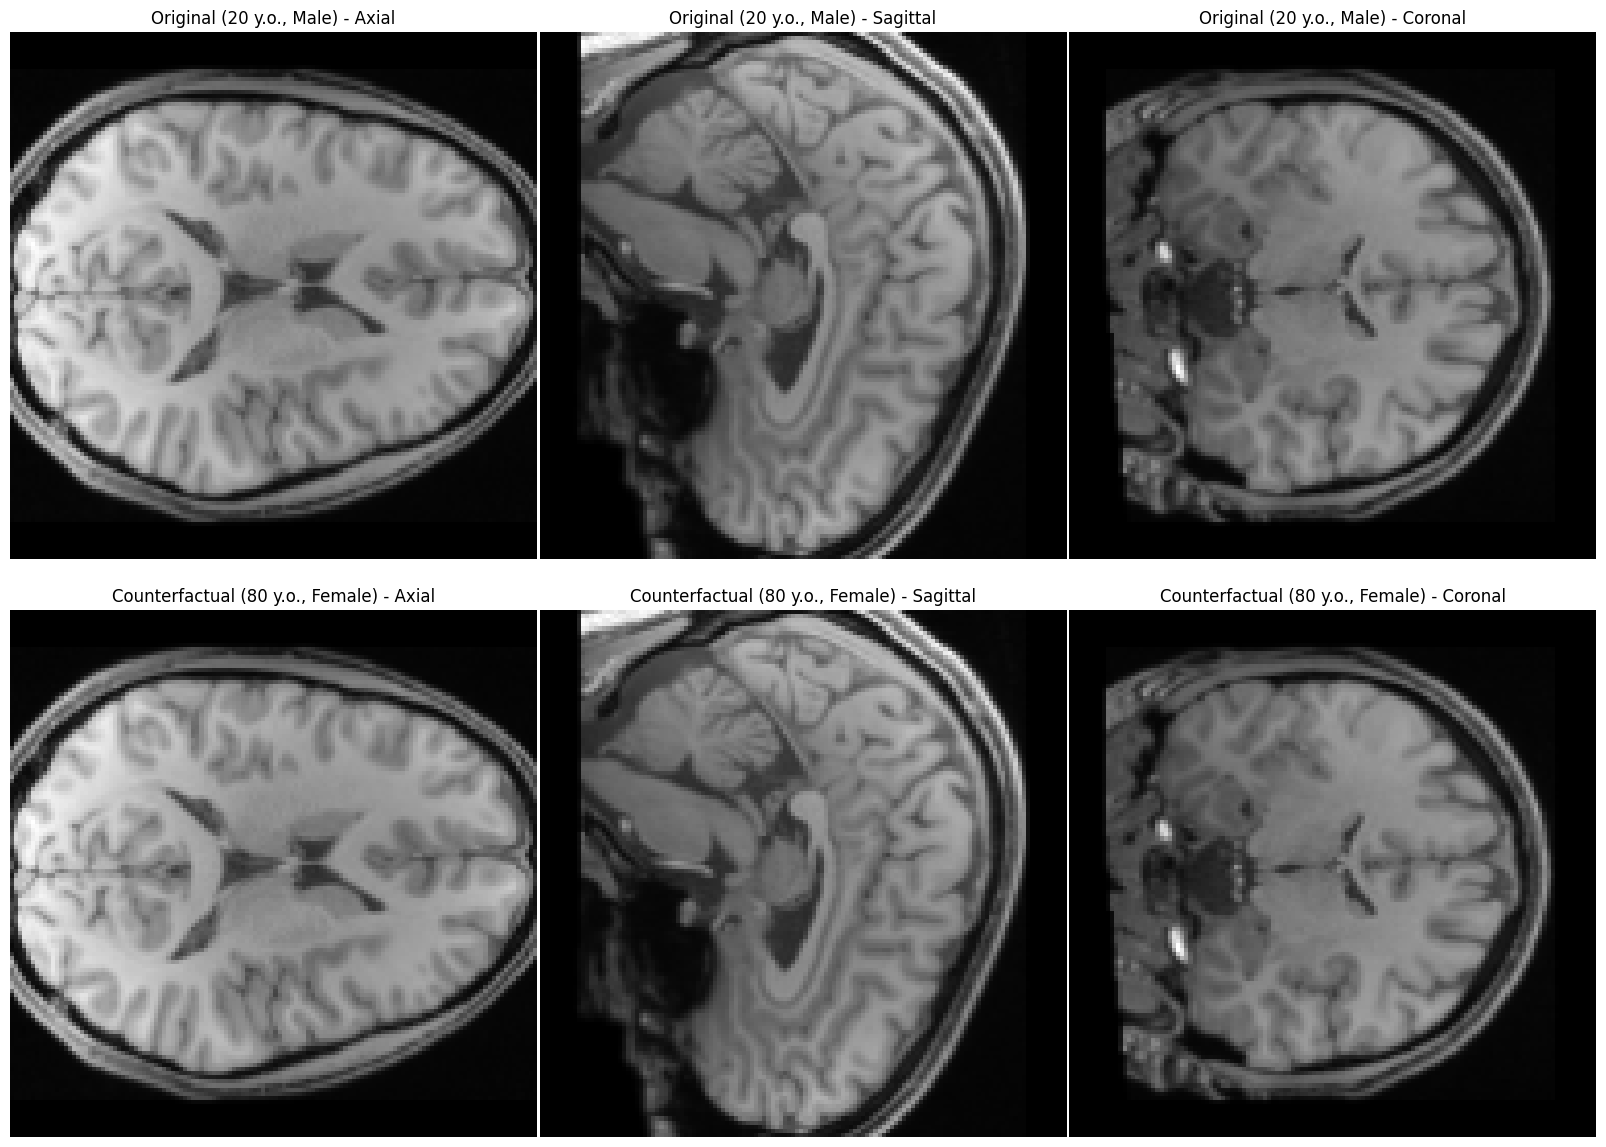

In [25]:
generator = Generator(in_channels=3, condition_dim=4, init_features=32)

fake_image = generate_counterfactual_image(
    generator=generator,
    image_path="data/sub-BrainAge000022/anat/sub-BrainAge000022_T1w.nii.gz",
    origin_age=20,
    origin_gender="male",
    target_age=80,
    target_gender="female",
    normalize_func=custom_normalize,
    checkpoint_path="/home/ntdung/Medical/GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth",
    output_path="GAN/src/CounterSynth/Version_2/generated_samples/cf_1.png"
)

In [19]:
def visualize_age_gender_changes(generator, input_image_path, 
                                input_age=None, input_gender=None,
                                age_shifts=[-15, -10, -5, 5, 10, 15], 
                                genders=[0, 1], 
                                normalize_func=None, 
                                device=None, 
                                output_path=None):
    """
    Generate a matrix of counterfactual images with relative age changes and both genders
    Args:
        generator: Trained Generator model
        input_image_path: Path to input MRI image
        input_age: Age of subject in input image (if known)
        input_gender: Gender of subject in input image (0: male, 1: female, if known)
        age_shifts: List of age changes (-15, -10, -5, +5, +10, +15...)
        genders: List of genders (0: male, 1: female)
        normalize_func: Input normalization function (optional)
        device: Computing device (CPU/GPU)
        output_path: Path to save result image (optional)
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    generator.eval()
    generator.to(device)
    
    try:
        real_img = process_mri_nifti(input_image_path, img_size=128)
    except Exception as e:
        print(f"Error processing MRI: {e}")
        return
    
    if normalize_func is not None:
        real_img = normalize_func(real_img)
    else:
        for i in range(real_img.shape[1]):
            channel = real_img[:, i]
            channel_min = channel.min()
            channel_max = channel.max()
            if channel_max > channel_min:
                real_img[:, i] = (channel - channel_min) / (channel_max - channel_min)
            else:
                real_img[:, i] = torch.zeros_like(channel)
    
    real_img = real_img.to(device)
    
    # Calculate target ages
    target_ages = [max(1, min(100, input_age + shift)) for shift in age_shifts]
    
    num_age_shifts = len(age_shifts)
    num_genders = len(genders)
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    fig = plt.figure(figsize=(4 * num_age_shifts, 5 * (num_genders + 1)))
    
    # Show original image in the center of first row
    center_pos = num_age_shifts // 2 + 1
    ax = plt.subplot(num_genders + 1, num_age_shifts, center_pos)
    real_slice = real_img[0, 0].cpu().numpy()  # Use axial slice
    real_slice = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
    ax.imshow(real_slice, cmap='gray')
    gender_text = f", {'Female' if input_gender == 1 else 'Male'}" if input_gender is not None else ""
    ax.set_title(f"Original\n(Age: {input_age}{gender_text})", fontsize=14, fontweight='bold')
    ax.axis('off')
    
    for g_idx, gender in enumerate(genders):
        gender_name = "Female" if gender > 0.5 else "Male"
        gender_change = "" if input_gender is None else " (Changed)" if gender != input_gender else " (Original)"
        
        for a_idx, (age_shift, target_age) in enumerate(zip(age_shifts, target_ages)):
            cf_condition = create_condition_vector(target_age, gender)
            cf_condition = cf_condition.unsqueeze(0).to(device)
            
            with torch.no_grad():
                try:
                    result = generator(real_img, cf_condition)
                    if isinstance(result, tuple):
                        fake_img, _ = result
                    else:
                        fake_img = result
                except Exception as e:
                    print(f"Error generating image for age {target_age}, gender {gender}: {e}")
                    continue
            
            ax = plt.subplot(num_genders + 1, num_age_shifts, (g_idx + 1) * num_age_shifts + a_idx + 1)
            fake_slice = fake_img[0, 0].cpu().numpy()  # Use axial slice
            fake_slice = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
            ax.imshow(fake_slice, cmap='gray')
            
            shift_text = f"+{age_shift}" if age_shift > 0 else f"{age_shift}"
            ax.set_title(f"Age: {target_age} ({shift_text})\nGender: {gender_name}{gender_change}", fontsize=12)
            ax.axis('off')
    
    plt.tight_layout(pad=0.5, h_pad=0.3, w_pad=0.2)
    
    if output_path:
        output_dir = os.path.dirname(output_path)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved matrix of results to: {output_path}")
    
    plt.show()

/tmp/ipykernel_1043/2325862063.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint

Saved matrix of results to: GAN/src/CounterSynth/Version_2/generated_samples/age_gender_matrix_1.png


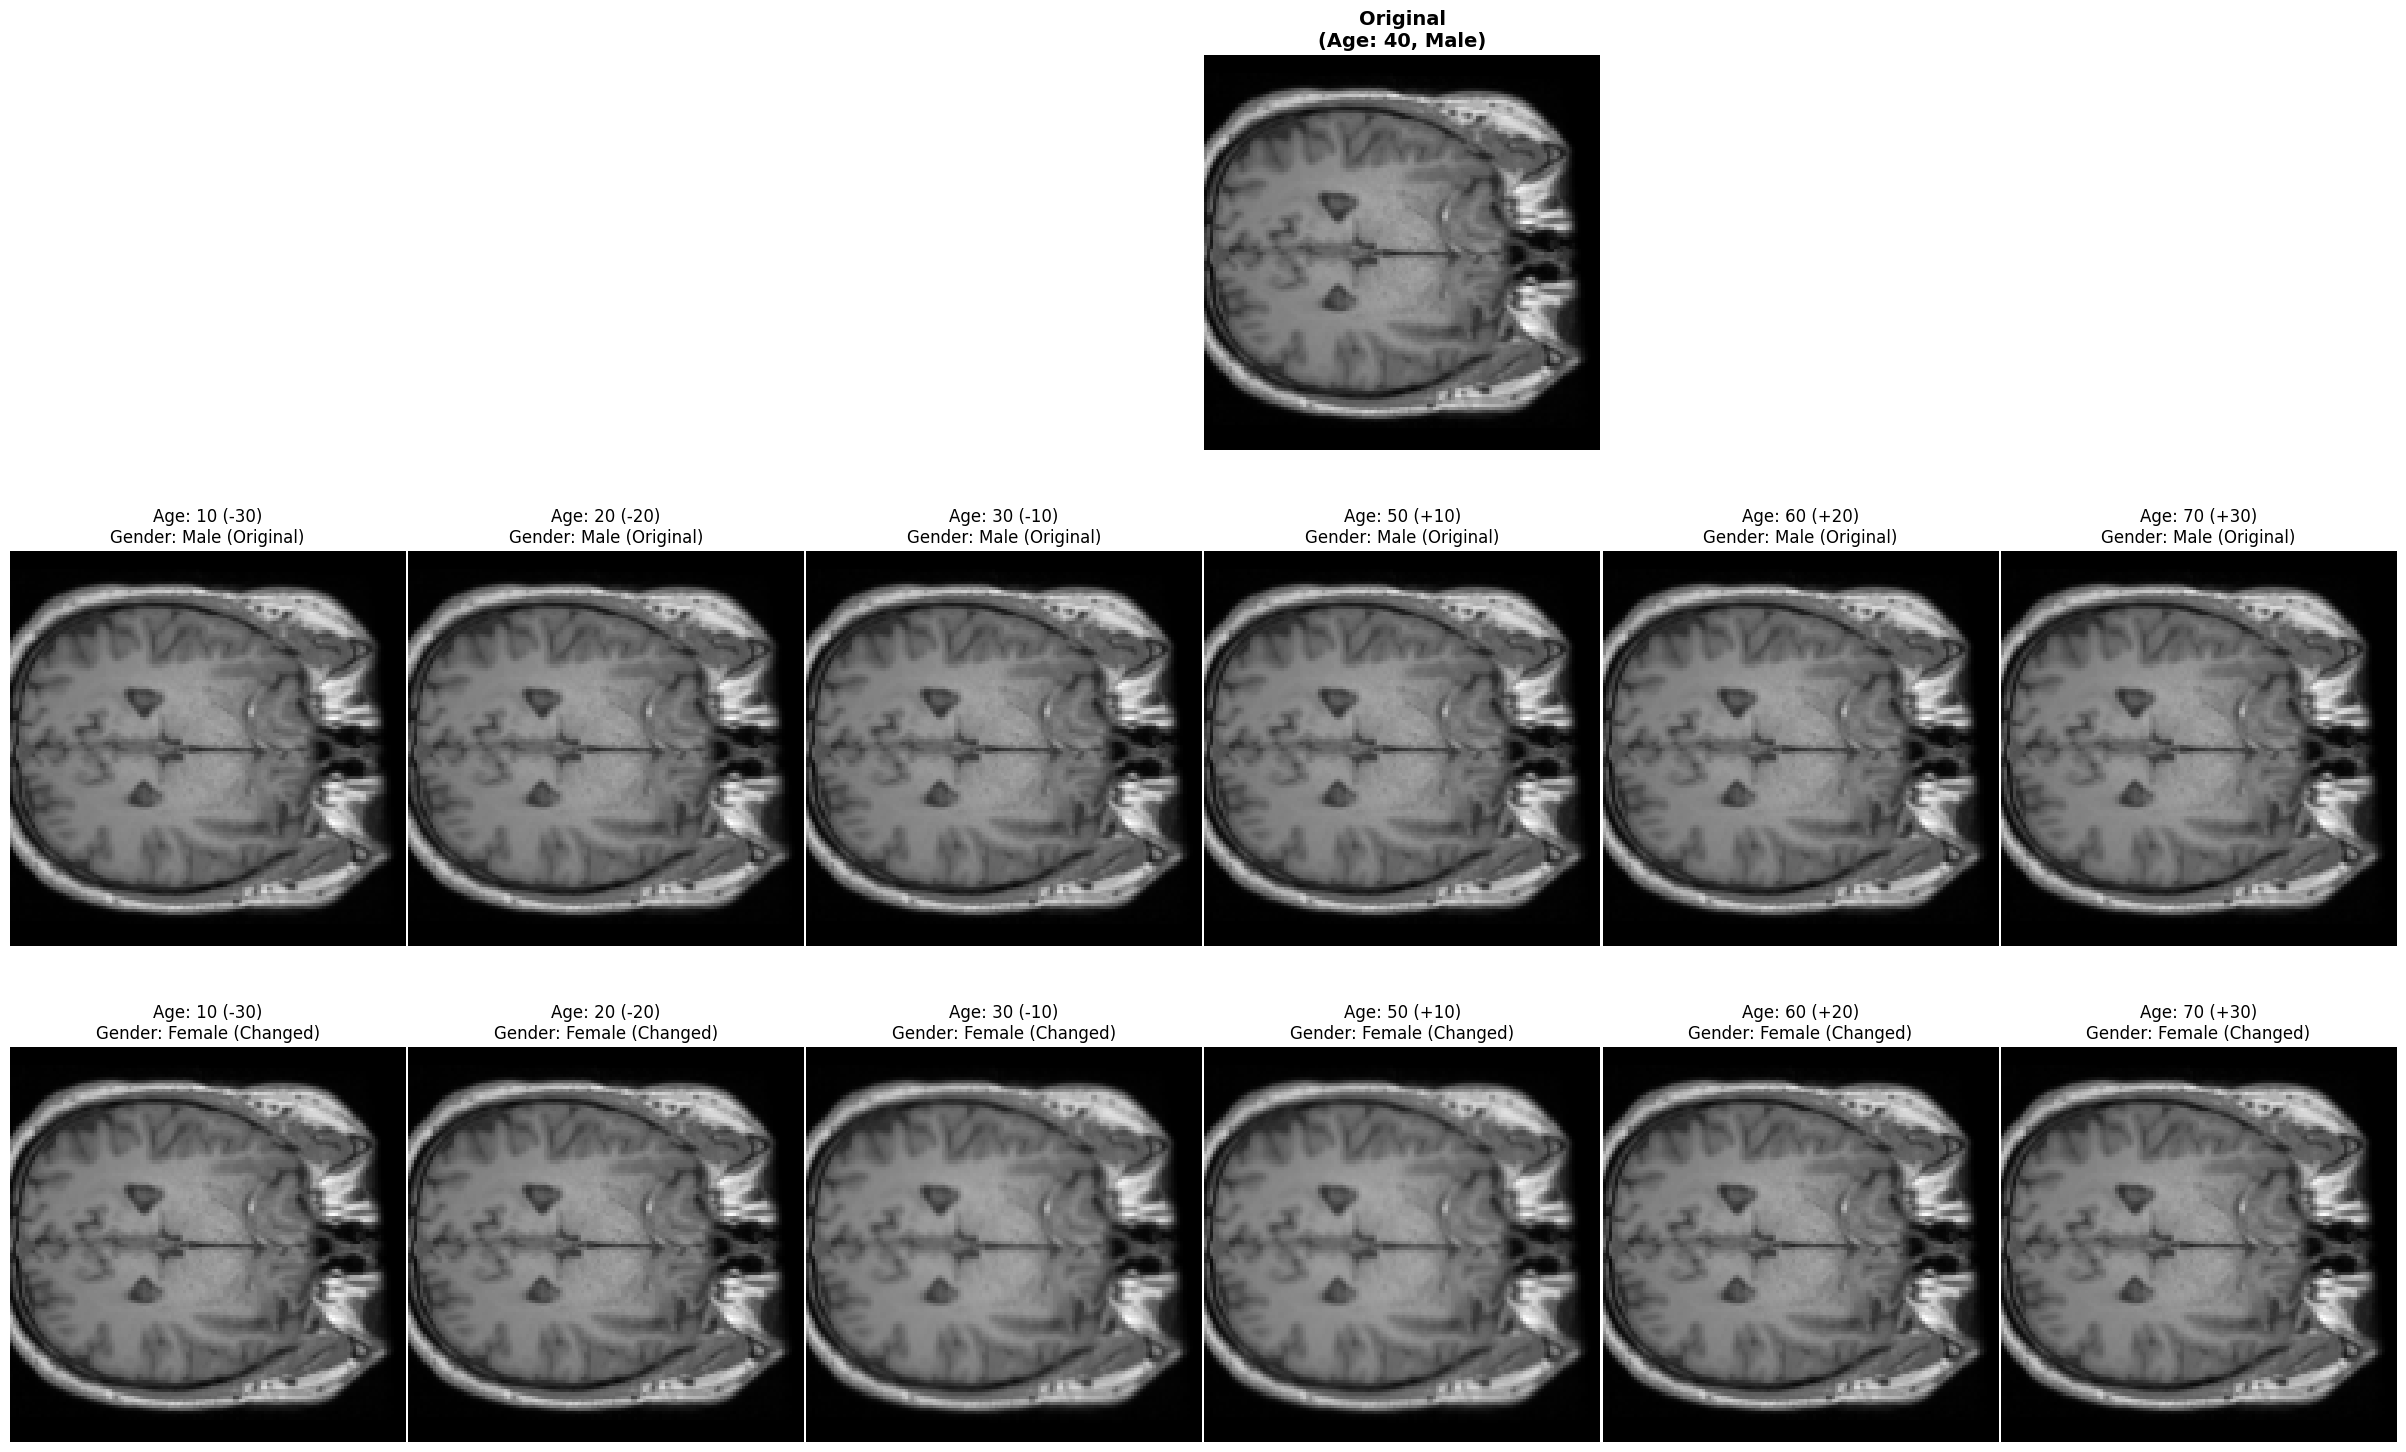

In [20]:
generator = Generator(in_channels=3, condition_dim=4, init_features=32)
checkpoint = torch.load("GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth")
generator.load_state_dict(checkpoint['generator'])

visualize_age_gender_changes(
    generator=generator,
    input_image_path="data/sub-BrainAge000063/anat/sub-BrainAge000063_T1w.nii.gz",
    input_age=40,
    input_gender=0,
    age_shifts=[-30, -20, -10, 10, 20, 30],
    genders=[0, 1],
    output_path="GAN/src/CounterSynth/Version_2/generated_samples/age_gender_matrix_1.png"
)

## Visualization

In [26]:
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
import warnings
warnings.filterwarnings('ignore')

def visualize_flow_fields(flow, save_path=None):
    """
    Visualize single flow field - one magnitude and one vector field
    
    Args:
        flow: Single flow tensor [B, 2, H, W] 
        save_path: Path to save image
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    flow_np = flow[0].detach().cpu().numpy()  # [2, H, W]
    
    # Flow magnitude
    flow_magnitude = np.sqrt(flow_np[0]**2 + flow_np[1]**2)
    
    # 1. Flow magnitude
    im1 = axes[0].imshow(flow_magnitude, cmap='jet', alpha=0.8)
    axes[0].set_title('Flow Magnitude', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # 2. Flow vectors (subsampled for clarity)
    H, W = flow_np.shape[1], flow_np.shape[2]
    step = max(H // 20, W // 20, 4)
    
    y, x = np.mgrid[0:H:step, 0:W:step]
    u = flow_np[0][::step, ::step]
    v = flow_np[1][::step, ::step]
    
    background = np.zeros_like(flow_magnitude)
    axes[1].imshow(background, cmap='gray', alpha=0.3)
    
    axes[1].quiver(x, y, u, v, flow_magnitude[::step, ::step], 
                   cmap='jet', scale=20, alpha=0.8, width=0.003)
    axes[1].set_title('Flow Vectors', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    axes[1].set_xlim(0, W)
    axes[1].set_ylim(H, 0)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Flow visualization saved to: {save_path}")
    
    plt.show()

def visualize_difference_maps(real_img, fake_img, save_path=None):
    """
    Visualize differences between real and generated images
    
    Args:
        real_img: Real image tensor [B, C, H, W]
        fake_img: Generated image tensor [B, C, H, W]
        save_path: Path to save image
    """
    slice_names = ["Axial", "Sagittal", "Coronal"]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i in range(3):
        real_slice = real_img[0, i].numpy()
        fake_slice = fake_img[0, i].numpy()
        
        real_norm = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
        fake_norm = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
        
        diff = np.abs(real_norm - fake_norm)
        
        im = axes[i].imshow(diff, cmap='hot', alpha=0.8)
        axes[i].set_title(f'Difference Map - {slice_names[i]}', fontsize=12, fontweight='bold')
        axes[i].axis('off')
        
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        
        mean_diff = np.mean(diff)
        max_diff = np.max(diff)
        axes[i].text(0.02, 0.98, f'Mean: {mean_diff:.3f}\nMax: {max_diff:.3f}', 
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Difference maps saved to: {save_path}")
    
    plt.show()

def calculate_ssim_metrics(real_img, fake_img):
    """
    Calculate SSIM metrics for 3 slices
    
    Args:
        real_img: Real image tensor [B, C, H, W]
        fake_img: Generated image tensor [B, C, H, W]
    Returns:
        dict: Dictionary containing SSIM metrics
    """
    real_np = real_img.squeeze().numpy()
    fake_np = fake_img.squeeze().numpy()
    
    slice_names = ["Axial", "Sagittal", "Coronal"]
    ssim_scores = []
    
    for i in range(3):
        real_slice = real_np[i]
        fake_slice = fake_np[i]
        
        real_norm = (real_slice - real_slice.min()) / (real_slice.max() - real_slice.min() + 1e-8)
        fake_norm = (fake_slice - fake_slice.min()) / (fake_slice.max() - fake_slice.min() + 1e-8)
        
        ssim_score = ssim(real_norm, fake_norm, data_range=1.0)
        ssim_scores.append(ssim_score)
    
    overall_ssim = np.mean(ssim_scores)
    
    return {
        'slice_names': slice_names,
        'ssim_scores': ssim_scores,
        'overall_ssim': overall_ssim
    }

def plot_ssim_results(ssim_metrics, save_path=None):
    """   
    Args:
        ssim_metrics: Dictionary containing SSIM metrics
        save_path: Path to save image
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    slice_names = ssim_metrics['slice_names']
    ssim_scores = ssim_metrics['ssim_scores']
    slice_colors = ['lightcoral', 'skyblue', 'lightgreen']
    
    bars = ax.bar(slice_names, ssim_scores, color=slice_colors, alpha=0.8, 
                 edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('SSIM Score', fontsize=12)
    ax.set_ylim(0, 1.0)
    
    for bar, score in zip(bars, ssim_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{score:.3f}', ha='center', va='bottom', 
               fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"SSIM results saved to: {save_path}")
    
    plt.show()

def comprehensive_counterfactual_analysis(generator, image_path, origin_age, origin_gender,
                                         target_age, target_gender, checkpoint_path, 
                                         output_dir="results", device=None):
    """
    Comprehensive analysis function with proper origin parameters
    
    Args:
        generator: Generator model
        image_path: Path to input MRI image
        origin_age: Original age
        origin_gender: Original gender ("male"/"female" or 0/1)
        target_age: Target age
        target_gender: Target gender ("male"/"female" or 0/1)
        checkpoint_path: Path to model checkpoint
        output_dir: Directory to save results
        device: Computing device
    Returns:
        dict: Dictionary containing results
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Using device: {device}")
    print("="*50)
    
    print("Loading model...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    generator.eval()
    generator.to(device)
    
    print("Processing image...")
    real_img = process_mri_nifti(image_path)
    real_img = real_img.to(device)
    
    print("Creating condition...")
    cf_condition = create_condition_vector(target_age, target_gender)
    cf_condition = cf_condition.unsqueeze(0).to(device)
    print(f"✓ Origin: Age={origin_age}, Gender={origin_gender}")
    print(f"✓ Target: Age={target_age}, Gender={target_gender}")
    
    print("Generating counterfactual image...")
    with torch.no_grad():
        fake_img, flow = generator(real_img, cf_condition)
    
    fake_img_cpu = fake_img.detach().cpu()
    real_img_cpu = real_img.detach().cpu()
    
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*50)
    print("VISUALIZATIONS")
    print("="*50)
    
    # 1. Original vs Generated comparison with proper parameters
    print("1. Displaying original vs generated images...")
    comparison_path = os.path.join(output_dir, "comparison.png")
    display_comparison(real_img_cpu, fake_img_cpu, origin_age, origin_gender, 
                      target_age, target_gender, comparison_path)
    
    # 2. Flow visualization (single flow field)
    print("2. Visualizing flow fields...")
    flow_path = os.path.join(output_dir, "flow_fields.png")
    visualize_flow_fields(flow, flow_path)
    
    # 3. Difference maps
    print("3. Visualizing difference maps...")
    diff_path = os.path.join(output_dir, "difference_maps.png")
    visualize_difference_maps(real_img_cpu, fake_img_cpu, diff_path)
    
    # 4. SSIM results with better formatting
    print("4. Calculating and plotting SSIM...")
    ssim_metrics = calculate_ssim_metrics(real_img_cpu, fake_img_cpu)
    ssim_path = os.path.join(output_dir, "ssim_results.png")
    plot_ssim_results(ssim_metrics, ssim_path)
    
    print("\n" + "="*50)
    print("ANALYSIS COMPLETE!")
    print(f"📁 Results saved to: {output_dir}")
    print(f"📊 Overall SSIM: {ssim_metrics['overall_ssim']:.4f}")
    print("="*50)
    
    return {
        'real_img': real_img_cpu,
        'fake_img': fake_img_cpu,
        'flow': flow,
        'ssim_metrics': ssim_metrics
    }

Using device: cuda
Loading model...
Processing image...
Creating condition...
✓ Origin: Age=20, Gender=female
✓ Target: Age=65, Gender=female
Generating counterfactual image...

VISUALIZATIONS
1. Displaying original vs generated images...
Comparison image saved to: GAN/src/CounterSynth/Version_2/analysis_results_1/comparison.png


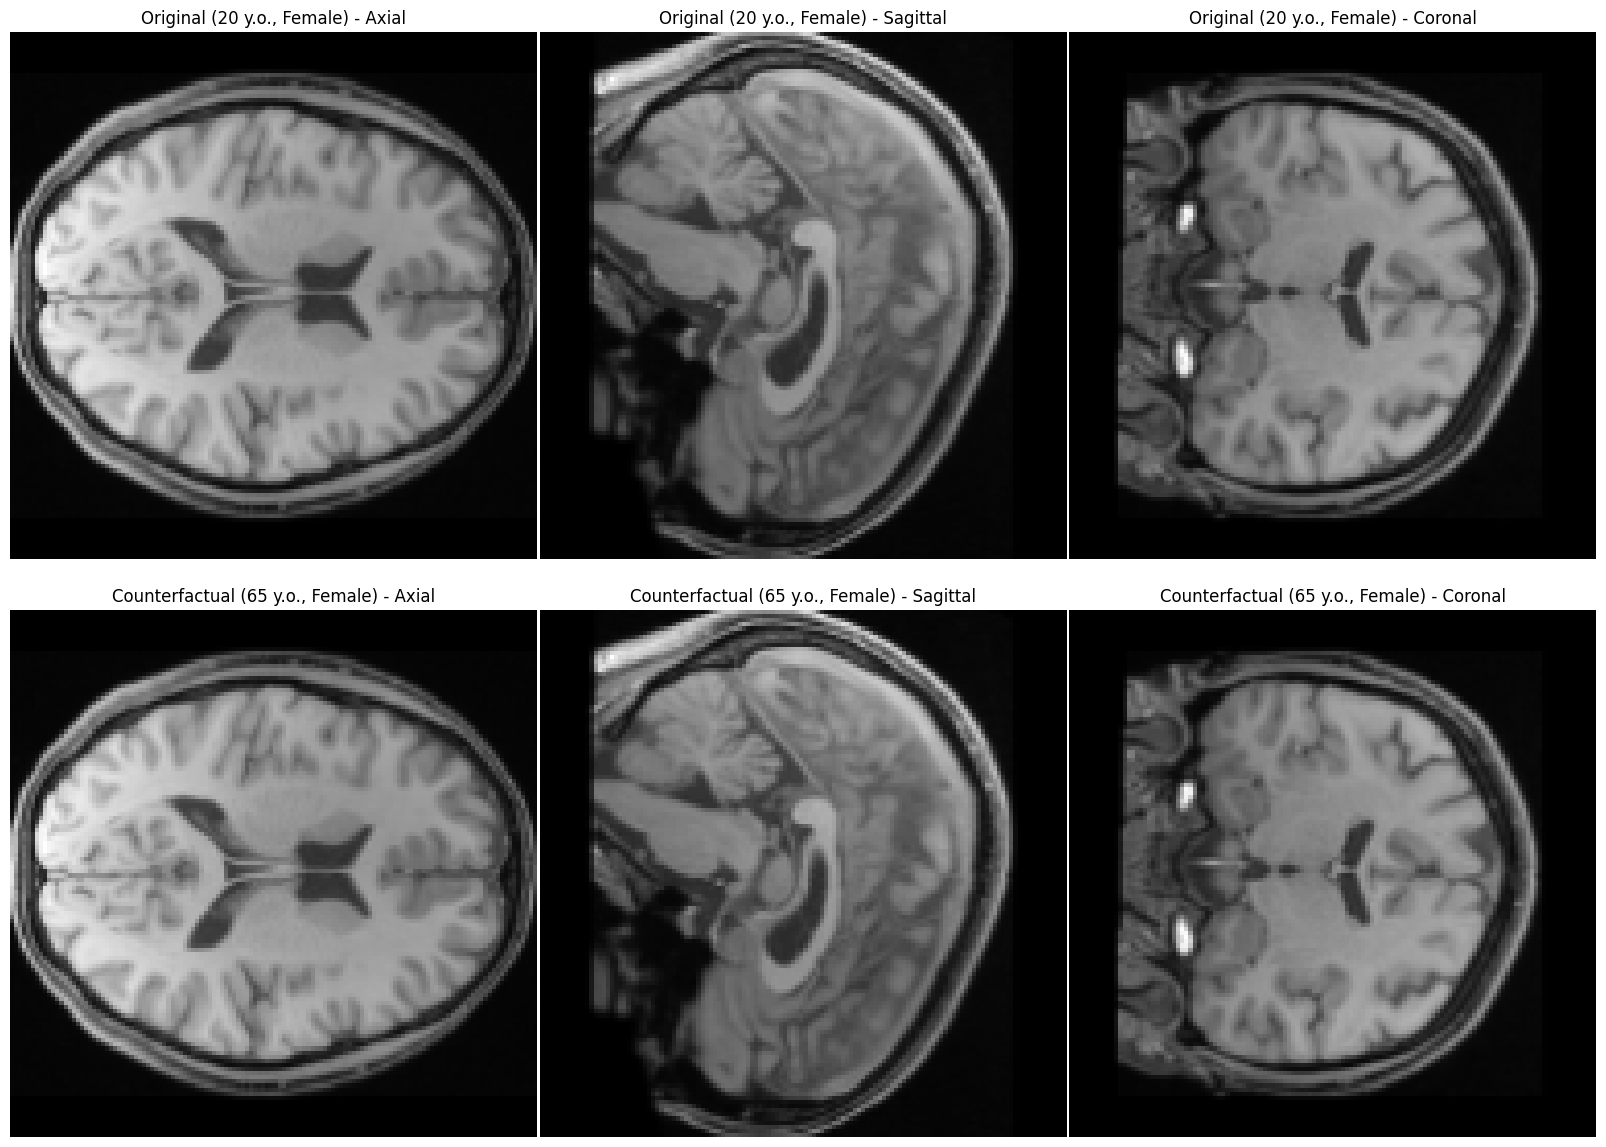

2. Visualizing flow fields...
Flow visualization saved to: GAN/src/CounterSynth/Version_2/analysis_results_1/flow_fields.png


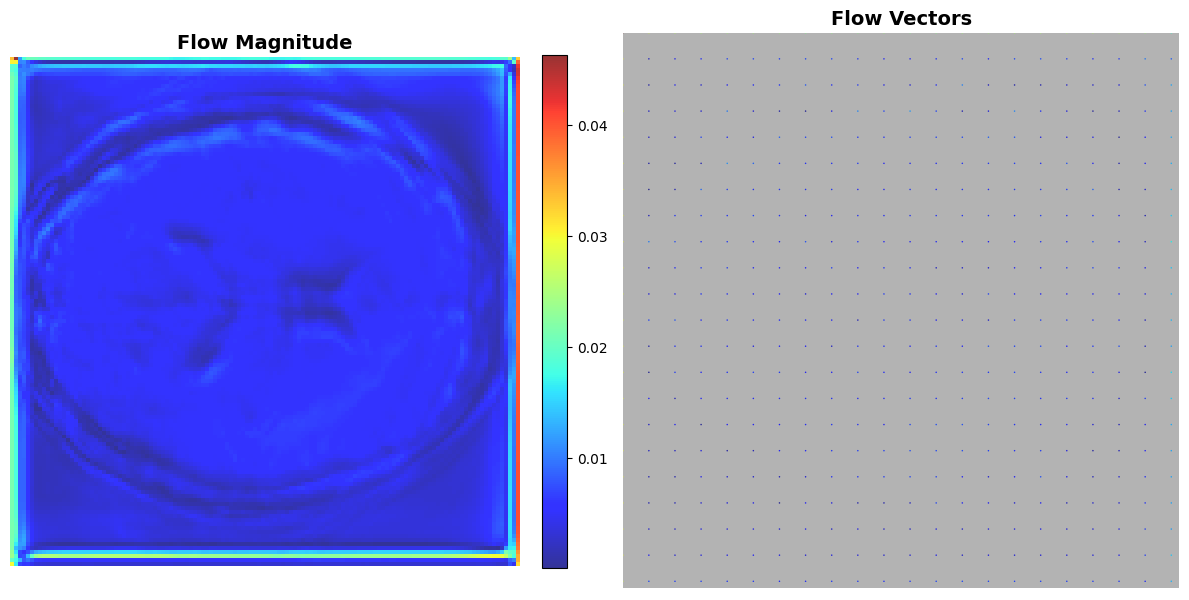

3. Visualizing difference maps...
Difference maps saved to: GAN/src/CounterSynth/Version_2/analysis_results_1/difference_maps.png


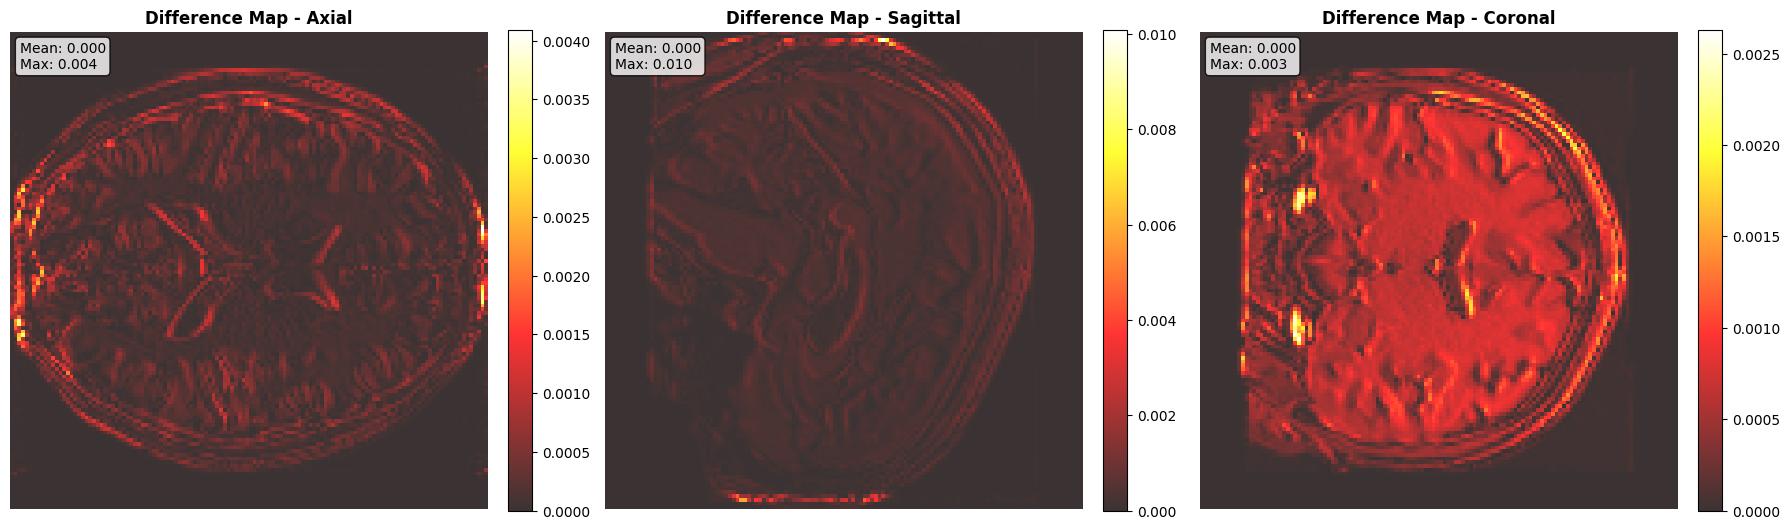

4. Calculating and plotting SSIM...
SSIM results saved to: GAN/src/CounterSynth/Version_2/analysis_results_1/ssim_results.png


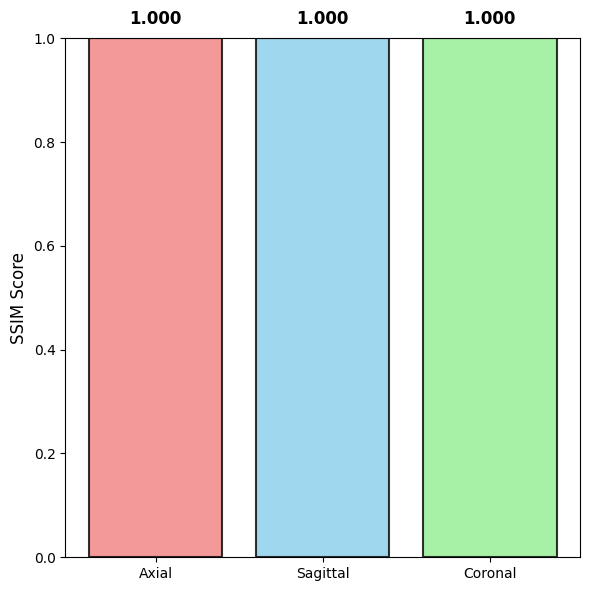


ANALYSIS COMPLETE!
📁 Results saved to: GAN/src/CounterSynth/Version_2/analysis_results_1
📊 Overall SSIM: 1.0000


In [27]:
generator = Generator(in_channels=3, condition_dim=4, init_features=32)

results = comprehensive_counterfactual_analysis(
    generator=generator,
    image_path="data/sub-BrainAge000023/anat/sub-BrainAge000023_T1w.nii.gz",
    origin_age=20,
    origin_gender="female",
    target_age=65,
    target_gender="female",
    checkpoint_path="GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth",
    output_dir="GAN/src/CounterSynth/Version_2/analysis_results_1",
)

Using device: cuda
Loading model...
Processing image...
Creating condition...
✓ Origin: Age=20, Gender=female
✓ Target: Age=65, Gender=female
Generating counterfactual image...

VISUALIZATIONS
1. Displaying original vs generated images...
Comparison image saved to: GAN/src/CounterSynth/Version_2/analysis_results_2/comparison.png


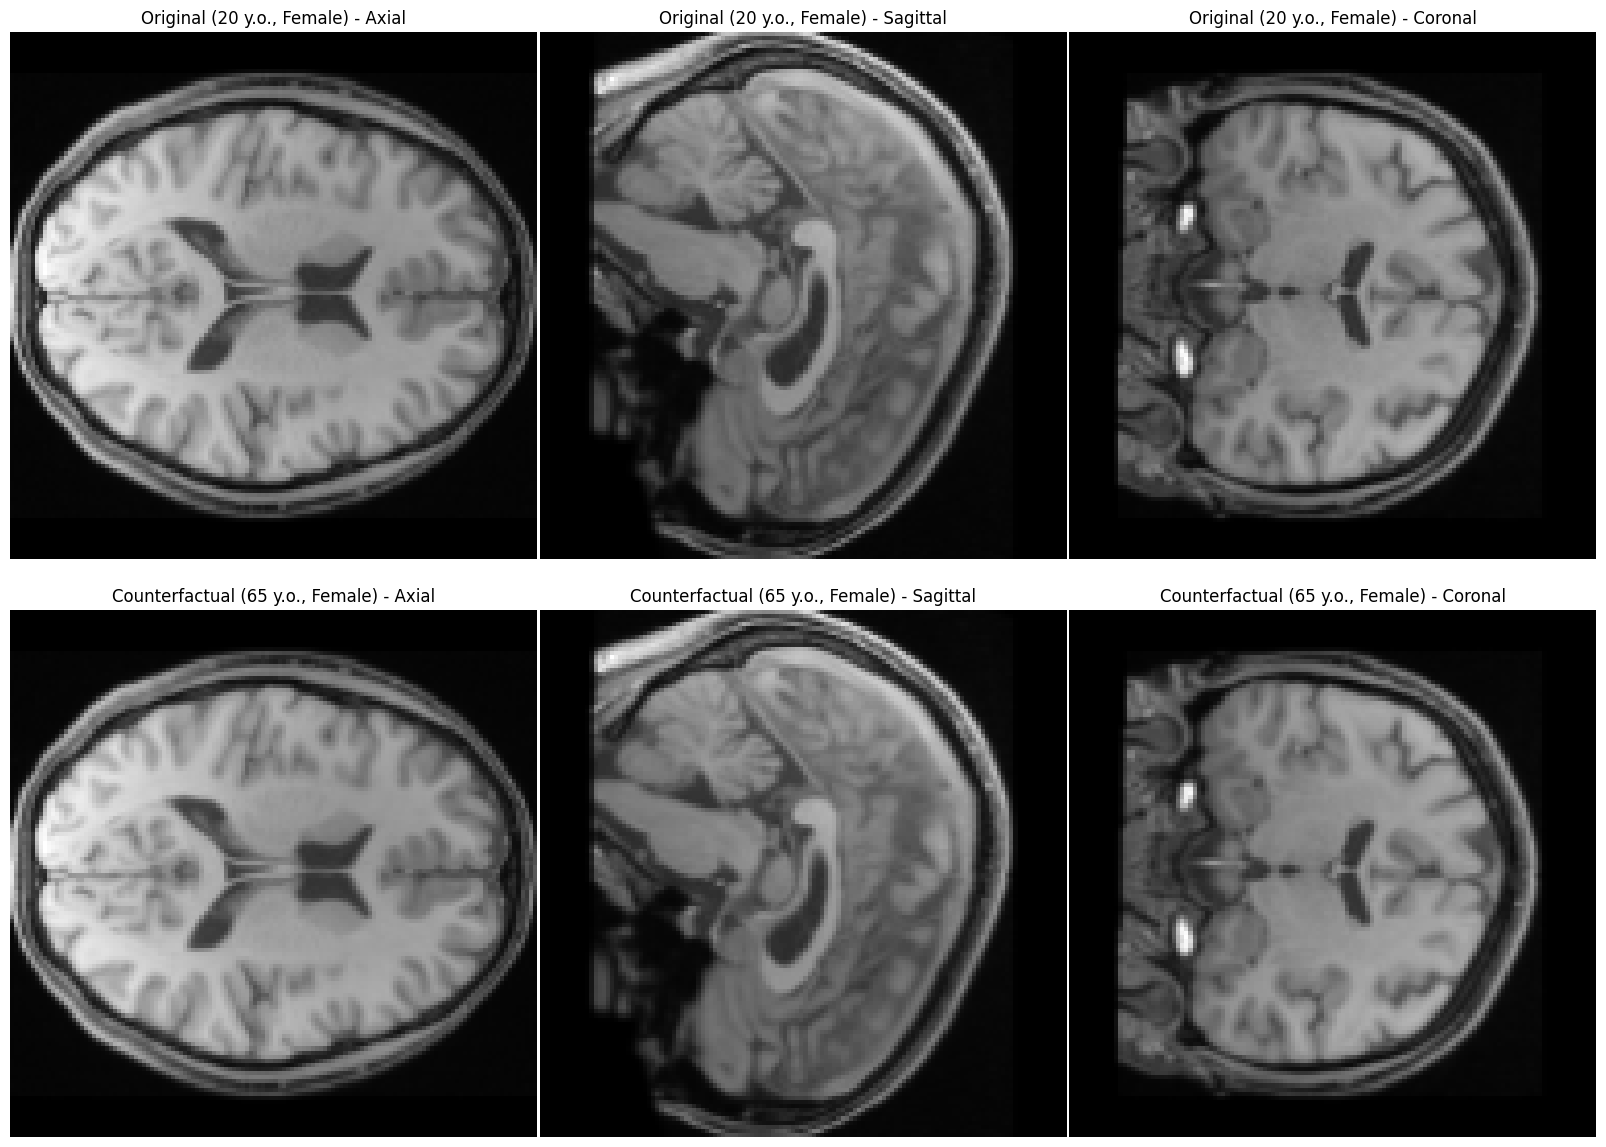

2. Visualizing flow fields...
Flow visualization saved to: GAN/src/CounterSynth/Version_2/analysis_results_2/flow_fields.png


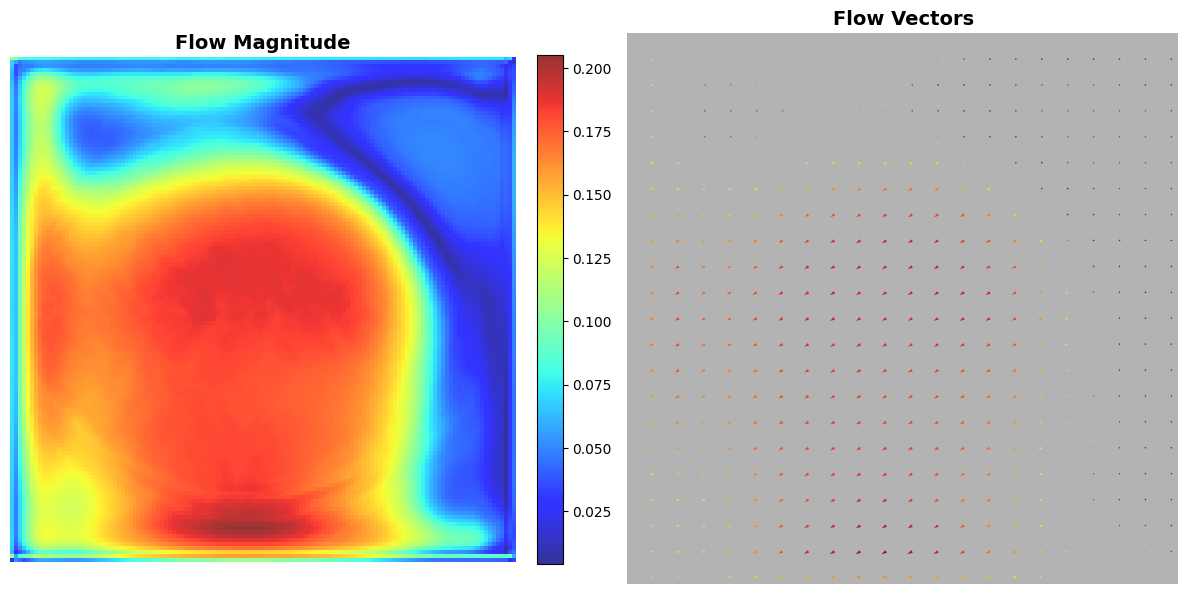

3. Visualizing difference maps...
Difference maps saved to: GAN/src/CounterSynth/Version_2/analysis_results_2/difference_maps.png


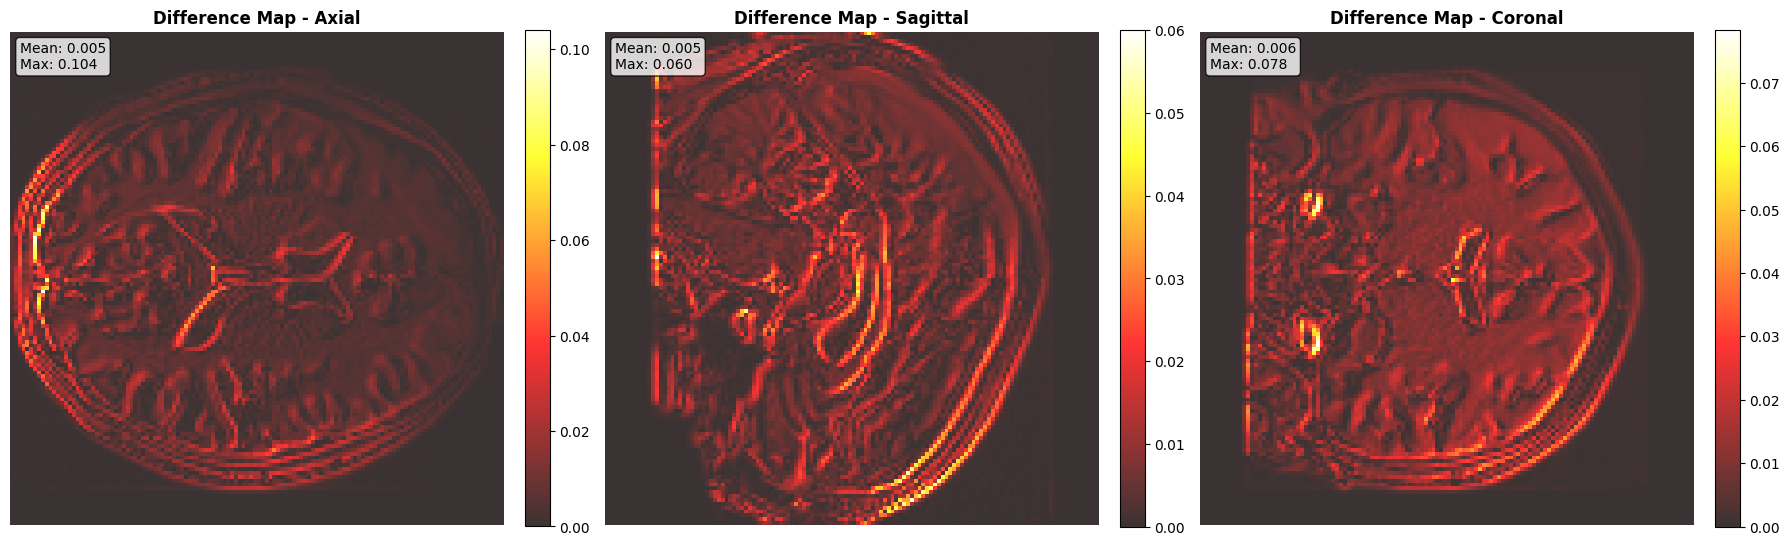

4. Calculating and plotting SSIM...
SSIM results saved to: GAN/src/CounterSynth/Version_2/analysis_results_2/ssim_results.png


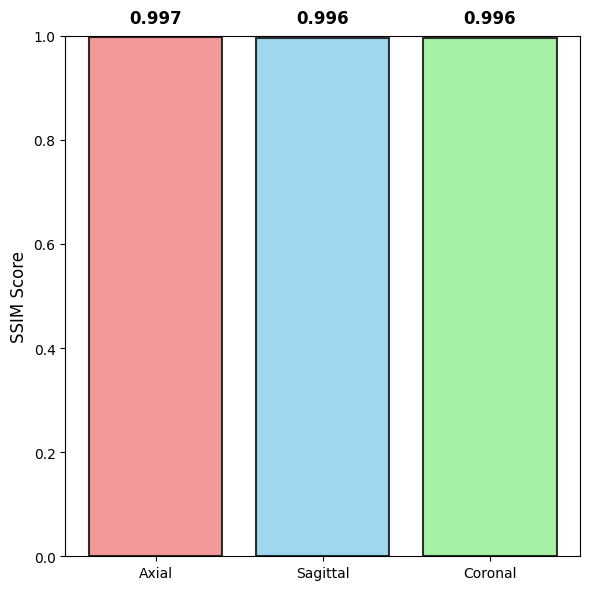


ANALYSIS COMPLETE!
📁 Results saved to: GAN/src/CounterSynth/Version_2/analysis_results_2
📊 Overall SSIM: 0.9965


In [28]:
generator = Generator(in_channels=3, condition_dim=4, init_features=32)

results = comprehensive_counterfactual_analysis(
    generator=generator,
    image_path="data/sub-BrainAge000023/anat/sub-BrainAge000023_T1w.nii.gz",
    origin_age=20,
    origin_gender="female",
    target_age=65,
    target_gender="female",
    checkpoint_path="GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_30.pth",
    output_dir="GAN/src/CounterSynth/Version_2/analysis_results_2",
)

In [36]:
from scipy import linalg
from torchvision import transforms
from torchvision.models import inception_v3
from PIL import Image

def generate_counterfactual_dataset(data_dir, participants_file, checkpoint_path, 
                                  output_dir, generator, num_samples=None, 
                                  device=None):
    """
    Generate counterfactual dataset for FID evaluation
    Args:
        data_dir: Path to original data directory
        participants_file: Path to participants.xlsx
        checkpoint_path: Path to trained model checkpoint
        output_dir: Directory to save generated images
        generator: Generator model
        num_samples: Number of samples to generate (None for all)
        device: Computing device
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    os.makedirs(output_dir, exist_ok=True)
    real_imgs_dir = os.path.join(output_dir, "real_images")
    fake_imgs_dir = os.path.join(output_dir, "fake_images")
    os.makedirs(real_imgs_dir, exist_ok=True)
    os.makedirs(fake_imgs_dir, exist_ok=True)
    
    print(f"Loading participants data from: {participants_file}")
    participants_df = pd.read_excel(participants_file)
    print(f"Total subjects in dataset: {len(participants_df)}")
    
    if num_samples and num_samples < len(participants_df):
        participants_df = participants_df.sample(n=num_samples, random_state=42)
        print(f"Using {num_samples} samples for generation")
    
    print(f"Loading generator from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if 'generator' in checkpoint:
        generator.load_state_dict(checkpoint['generator'])
    else:
        generator.load_state_dict(checkpoint)
    generator.eval()
    generator.to(device)
    
    successful_generations = 0
    failed_generations = 0
    
    print("Starting counterfactual image generation...")
    for idx, row in tqdm(participants_df.iterrows(), total=len(participants_df)):
        try:
            subject_id = row['subject_id']
            origin_age = float(row['subject_age'])
            origin_gender = row['subject_sex']
            
            origin_gender_full = "male" if origin_gender.lower() == 'm' else "female"
            
            # Create counterfactual conditions (opposite gender, different age group)
            target_gender_full = "female" if origin_gender_full == "male" else "male"
            
            if origin_age < 30:
                target_age = random.uniform(50, 80)
            elif origin_age <= 50:
                target_age = random.uniform(20, 30) if random.random() > 0.5 else random.uniform(60, 80)
            else:
                target_age = random.uniform(20, 40)
            
            image_path = os.path.join(data_dir, subject_id, "anat", f"{subject_id}_T1w.nii.gz")
            
            if not os.path.exists(image_path):
                print(f"Warning: Image not found for {subject_id}")
                failed_generations += 1
                continue
            
            real_img = process_mri_nifti(image_path)
            if real_img is None:
                failed_generations += 1
                continue
                
            real_img = custom_normalize(real_img)
            real_img = real_img.to(device)
            
            cf_condition = create_condition_vector(target_age, target_gender_full)
            cf_condition = cf_condition.unsqueeze(0).to(device)
            
            with torch.no_grad():
                result = generator(real_img, cf_condition)
                if isinstance(result, tuple):
                    fake_img, _ = result
                else:
                    fake_img = result
            
            real_img_cpu = real_img.detach().cpu()
            fake_img_cpu = fake_img.detach().cpu()
            
            save_mri_slices_as_image(real_img_cpu[0], 
                                   os.path.join(real_imgs_dir, f"{subject_id}_real.png"))
            save_mri_slices_as_image(fake_img_cpu[0], 
                                   os.path.join(fake_imgs_dir, f"{subject_id}_fake.png"))
            
            successful_generations += 1
            
        except Exception as e:
            print(f"Error processing {subject_id}: {e}")
            failed_generations += 1
            continue
    
    print(f"\nGeneration completed!")
    print(f"Successful: {successful_generations}")
    print(f"Failed: {failed_generations}")
    print(f"Real images saved to: {real_imgs_dir}")
    print(f"Fake images saved to: {fake_imgs_dir}")
    
    return real_imgs_dir, fake_imgs_dir

def save_mri_slices_as_image(img_tensor, output_path):
    """
    Save MRI slices as a single RGB image
    Args:
        img_tensor: Image tensor [3, H, W] (3 slices as channels)
        output_path: Path to save image
    """
    # Convert tensor to numpy and normalize to [0, 255]
    img_np = img_tensor.numpy()
    
    # Normalize each channel independently
    for i in range(3):
        channel = img_np[i]
        if channel.max() > channel.min():
            img_np[i] = (channel - channel.min()) / (channel.max() - channel.min())
        else:
            img_np[i] = np.zeros_like(channel)
    
    # Convert to [H, W, 3] and scale to [0, 255]
    img_np = np.transpose(img_np, (1, 2, 0))
    img_np = (img_np * 255).astype(np.uint8)
    
    img_pil = Image.fromarray(img_np)
    img_pil.save(output_path)

def calculate_inception_features(image_dir, batch_size=32, device=None):
    """
    Calculate Inception features for images in directory
    Args:
        image_dir: Directory containing images
        batch_size: Batch size for processing
        device: Computing device
    Returns:
        features: Numpy array of features
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = torch.nn.Identity()
    model.eval()
    model.to(device)
    
    transform = transforms.Compose([
        transforms.Resize((299, 299)),  # Inception input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Get all image paths
    image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                   if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"Processing {len(image_paths)} images from {image_dir}")
    
    features_list = []
    
    for i in tqdm(range(0, len(image_paths), batch_size)):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = []
        
        for path in batch_paths:
            try:
                img = Image.open(path).convert('RGB')
                img_tensor = transform(img)
                batch_images.append(img_tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                continue
        
        if not batch_images:
            continue
            
        batch_tensor = torch.stack(batch_images).to(device)
        
        with torch.no_grad():
            features = model(batch_tensor)
            features_list.append(features.cpu().numpy())
    
    if not features_list:
        raise ValueError("No features extracted from images")
    
    all_features = np.vstack(features_list)
    print(f"Extracted features shape: {all_features.shape}")
    
    return all_features

def calculate_fid_score(real_features, fake_features):
    """
    Calculate FID score between real and fake features
    Args:
        real_features: Features from real images
        fake_features: Features from fake images
    Returns:
        fid_score: FID score (lower is better)
    """
    # Calculate mean and covariance for real and fake features
    mu_real = np.mean(real_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    
    mu_fake = np.mean(fake_features, axis=0)
    sigma_fake = np.cov(fake_features, rowvar=False)
    
    # Calculate FID
    diff = mu_real - mu_fake
    covmean, _ = linalg.sqrtm(sigma_real.dot(sigma_fake), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid_score = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    
    return fid_score

def evaluate_with_fid(data_dir, participants_file, checkpoint_path, generator, 
                     num_samples=500, output_dir="fid_evaluation", device=None):
    """
    Complete pipeline: Generate counterfactual dataset and calculate FID
    Args:
        data_dir: Path to original data directory
        participants_file: Path to participants.xlsx
        checkpoint_path: Path to trained model checkpoint
        generator: Generator model
        num_samples: Number of samples to generate
        output_dir: Directory to save generated images
        device: Computing device
    Returns:
        fid_score: Calculated FID score
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    real_imgs_dir, fake_imgs_dir = generate_counterfactual_dataset(
        data_dir=data_dir,
        participants_file=participants_file,
        checkpoint_path=checkpoint_path,
        output_dir=output_dir,
        generator=generator,
        num_samples=num_samples,
        device=device
    )
    
    print("\n" + "="*50)
    print("CALCULATING FID SCORE")
    print("="*50)
    
    # Calculate Inception features
    print("Extracting features from real images...")
    real_features = calculate_inception_features(real_imgs_dir, device=device)
    
    print("Extracting features from fake images...")
    fake_features = calculate_inception_features(fake_imgs_dir, device=device)
    
    print("Calculating FID score...")
    fid_score = calculate_fid_score(real_features, fake_features)
    
    print("\n" + "="*50)
    print("RESULTS")
    print("="*50)
    print(f"Number of real images: {len(real_features)}")
    print(f"Number of fake images: {len(fake_features)}")
    print(f"FID Score: {fid_score:.4f}")
    
    return fid_score

In [38]:
generator = Generator(in_channels=3, condition_dim=4, init_features=32)

fid_score = evaluate_with_fid(
    data_dir="data",
    participants_file="data/participants.xlsx", 
    checkpoint_path="GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth",
    generator=generator,
    num_samples=500,
    output_dir="fid_evaluation",
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

Loading participants data from: data/participants.xlsx
Total subjects in dataset: 4948
Using 500 samples for generation
Loading generator from: GAN/src/CounterSynth/Version_2/csynth_checkpoints_attn/checkpoint_epoch_100.pth
Starting counterfactual image generation...


100%|██████████| 500/500 [00:28<00:00, 17.82it/s] 



Generation completed!
Successful: 500
Failed: 0
Real images saved to: fid_evaluation/real_images
Fake images saved to: fid_evaluation/fake_images

CALCULATING FID SCORE
Extracting features from real images...
Processing 500 images from fid_evaluation/real_images


100%|██████████| 16/16 [00:04<00:00,  3.88it/s]


Extracted features shape: (500, 2048)
Extracting features from fake images...
Processing 500 images from fid_evaluation/fake_images


100%|██████████| 16/16 [00:03<00:00,  4.22it/s]


Extracted features shape: (500, 2048)
Calculating FID score...

RESULTS
Number of real images: 500
Number of fake images: 500
FID Score: 0.4841
